# Swan Teleco — Customer Churn & Retention Analysis

*Lead analyst deliverable · prepared for Eliza Schuyler, Retention Marketing Manager*

Swan Teleco's single-customer view covers 7,043 California customers. This notebook turns it into four things the retention team can act on this quarter:

1. A profile of who is leaving, and what they say their reasons are.
2. The factors that keep customers, plus a sign-up incentive costed against the \$2.50 per metric budget.
3. A Top-500 mailer list of the active customers most likely to leave, sized at the expected 20% uptake.
4. A churn risk score for every remaining customer, readable enough to use live on a service call.

---
### How to read and run this

The heavy lifting lives in a small unit-tested package, `swan/` (`config`, `data`, `features`, `model`, `viz`). The notebook orchestrates and narrates; the package does the work. That keeps every step importable, testable and re-runnable. Section 6 is the deliberate exception — the segmentation is exploratory, so it stays inline where you can read it.

One seed, `swan.config.RANDOM_STATE = 42`, governs everything random. Run top to bottom with `Kernel → Restart & Run All` and budget 5–7 minutes on a laptop, most of the extra time being the K-Means sweep in Section 6. It runs single-process by default, so raise `config.N_JOBS` if you have cores to spare. Setup is `pip install -r requirements.txt`; the test suite is `pytest -q`.

### Agenda
| # | Section | Delivers |
|---|---------|----------|
| 1 | Setup & data loading | Reproducible environment |
| 2 | Data quality & cleaning | Corruption and missingness handled, and explained |
| 3 | Exploratory data analysis | Churn drivers, distributions, correlations |
| 4 | Demographics & reasons for churn | Requirement 1 |
| 5 | Retention factors & the \$2.50 incentive | Requirement 2 |
| 6 | Customer segmentation (K-Means) | Churn and retention archetypes |
| 7 | Feature engineering | Justified transformations |
| 8 | Modelling & tuning | 4 classifiers, K-fold CV, GridSearch |
| 9 | Evaluation | ROC/PR/confusion, and what it means commercially |
| 10 | Deliverables | Requirements 3 & 4, plus saved files |
| 11 | Executive summary & recommendations | Stakeholder-ready |

## 1 · Setup & data loading

We import the project package rather than redefining its logic inline. On a fresh environment, uncomment the install line first.

In [1]:
# !pip install -r requirements.txt   # uncomment on a fresh environment

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# The Swan Teleco analytics package (local, unit-tested — see swan/ and tests/)
from swan import config, data, features, model, viz

viz.set_style()                 # apply the consistent Swan Teleco chart theme
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

print(f"Reproducibility seed : {config.RANDOM_STATE}")
print(f"Parallel jobs        : {config.N_JOBS}  (bump config.N_JOBS to -1 on a well-resourced machine)")
print(f"Data source          : {config.DATA_PATH.name}")

Reproducibility seed : 42
Parallel jobs        : 1  (bump config.N_JOBS to -1 on a well-resourced machine)
Data source          : customer_data.xlsx


In [2]:
# Load the raw workbook and immediately audit it. `load_clean` returns the cleaned
# frame plus a per-column quality report built from the *raw* data, so nothing is
# hidden before we have looked at it.
raw = data.load_raw()
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (7043, 31)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,Competitor had better devices


## 2 · Data quality checks & cleaning

Nothing gets analysed before it gets interrogated. The audit below turns up four things worth handling: PII, constant columns, target-leakage columns, and missing or corrupted values.

In [3]:
quality = data.quality_report(raw)
quality

,column,dtype,n_unique,n_missing,pct_missing,note
0,CustomerID,str,7043,0,0.00,PII
1,Count,int64,1,0,0.00,constant
2,Country,str,1,0,0.00,constant
3,State,str,1,0,0.00,constant
4,City,str,1129,0,0.00,PII
5,Zip Code,int64,1652,0,0.00,PII
6,Lat Long,str,1652,0,0.00,PII
7,Latitude,float64,1652,0,0.00,PII
8,Longitude,float64,1651,0,0.00,PII
9,Gender,str,2,0,0.00,


### 2.1 What the audit tells us

- **PII and geolocation** — `CustomerID`, `Lat Long`, `Latitude`, `Longitude`, `Zip Code`, `City`. Kept for joins and contact only, never fed to a model or shown in an aggregate. `CustomerID` survives purely as the mailer contact key.
- **Constant columns** — `Count` is always 1, `Country` always United States, `State` always California. Every customer is Californian, so there is no signal here to lose; they are dropped from modelling.
- **Leakage columns** — `Churn Label`, `Churn Value`, `Churn Reason`. A reason only gets recorded after someone leaves, so predicting churn from it would be circular. `Churn Value` is the target itself.
- **`Churn Reason` is 73% null**, covering 5,174 rows. That is missing by design rather than a data fault: only the 1,869 churners have a reason to give. Those rows stay for the "why" analysis and are never imputed.
- **`Total Charges` is stored as text**, which is usually the tell-tale sign that something is corrupted inside the column. Worth a closer look, which is next.

In [4]:
# --- The 'Total Charges' corruption, made visible -------------------------
coerced = pd.to_numeric(raw["Total Charges"], errors="coerce")
corrupt = raw.loc[coerced.isna(), ["CustomerID", "Tenure Months", "Monthly Charges", "Total Charges"]]
print(f"Non-numeric 'Total Charges' rows: {len(corrupt)}")
print(f"Their tenure values             : {sorted(corrupt['Tenure Months'].unique())}  <- all brand-new customers")
print(f"Stored value (repr)             : {raw.loc[coerced.isna(),'Total Charges'].iloc[0]!r}  <- a single blank space")
corrupt

Non-numeric 'Total Charges' rows: 11
Their tenure values             : [np.int64(0)]  <- all brand-new customers
Stored value (repr)             : ' '  <- a single blank space


,CustomerID,Tenure Months,Monthly Charges,Total Charges
2234,4472-LVYGI,0,52.55,
2438,3115-CZMZD,0,20.25,
2568,5709-LVOEQ,0,80.85,
2667,4367-NUYAO,0,25.75,
2856,1371-DWPAZ,0,56.05,
4331,7644-OMVMY,0,19.85,
4687,3213-VVOLG,0,25.35,
5104,2520-SGTTA,0,20.00,
5719,2923-ARZLG,0,19.70,
6772,4075-WKNIU,0,73.35,


All 11 bad values turn out to be a single blank space, and every one of them belongs to a customer whose `Tenure Months` is 0. They signed up but have not been billed a full cycle yet, so no total has accrued. Imputing `Total Charges = 0.0` is the defensible fix here; the column mean would invent spend that never happened.

`swan.data.clean()` does exactly that, and asserts that only zero-tenure rows were affected. If a future data refresh introduces a different kind of corruption, the pipeline fails loudly instead of quietly imputing the wrong thing.

In [5]:
# Clean + validate. `clean` fixes Total Charges, trims whitespace, de-duplicates
# and tightens dtypes. `validate` runs every row through a Pydantic schema
# (ranges, allowed categories) and raises if the contract is violated.
df = data.clean(raw)
data.validate(df, sample=None)   # validates all 7,043 rows; raises on any breach

print("Cleaned shape       :", df.shape)
print("Total Charges dtype :", df["Total Charges"].dtype)
print("Remaining nulls (excl. Churn Reason):")
print(df.drop(columns=["Churn Reason"]).isna().sum().loc[lambda s: s > 0] if
      df.drop(columns=['Churn Reason']).isna().any().any() else "  none — data is clean")

Cleaned shape       : (7043, 31)
Total Charges dtype : float64
Remaining nulls (excl. Churn Reason):
  none — data is clean


> **Verdict on quality.** No unexpected nulls, no duplicates, dtypes correct, the one corruption pattern explained and fixed, and every row validated against an explicit schema. Trustworthy enough to build on.

## 3 · Exploratory data analysis

Start from the headline number, then drill into the segments that move it.

Overall churn rate: 26.5%  (1,869 churned / 7,043 customers)


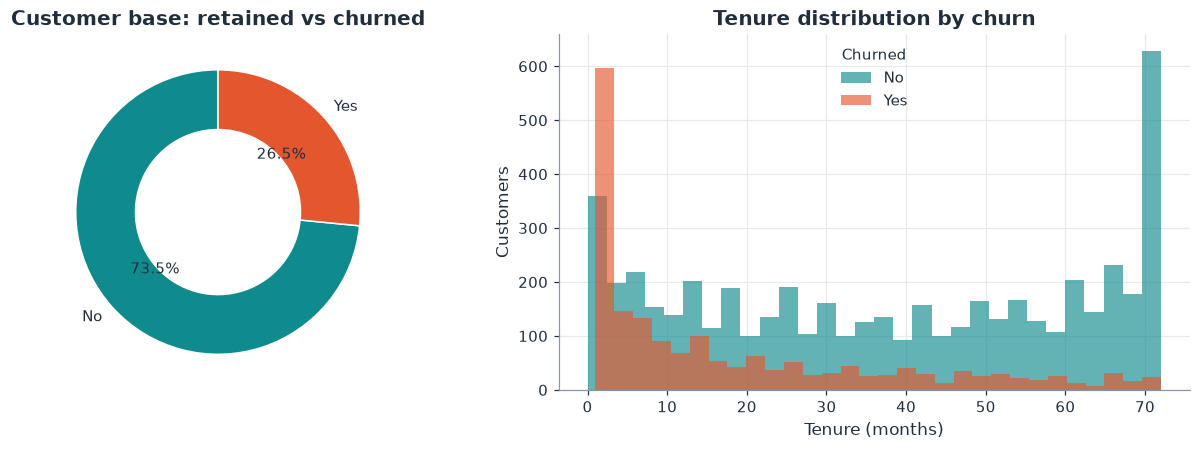

In [6]:
churn_rate = df[config.TARGET].mean()
counts = df["Churn Label"].value_counts()
print(f"Overall churn rate: {churn_rate:.1%}  ({counts.get('Yes',0):,} churned / {len(df):,} customers)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
# Donut
wedges, *_ = ax[0].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
                       colors=[viz.SWAN_TEAL, viz.SWAN_CORAL], startangle=90,
                       wedgeprops=dict(width=0.42, edgecolor="white"))
ax[0].set_title("Customer base: retained vs churned")
# Tenure distribution by churn
for label, g in df.groupby("Churn Label"):
    ax[1].hist(g["Tenure Months"], bins=30, alpha=0.65,
               label=label, color=viz.CHURN_COLORS[1 if label=="Yes" else 0])
ax[1].set_xlabel("Tenure (months)"); ax[1].set_ylabel("Customers")
ax[1].set_title("Tenure distribution by churn"); ax[1].legend(title="Churned")
plt.tight_layout(); plt.show()

Roughly one in four customers has left, which is a material leak rather than background noise. The tenure chart already tells the core story: churn is front-loaded. Leavers pile up in the first few months, while long-tenured customers rarely go anywhere. Retention effort is worth most early in the relationship.

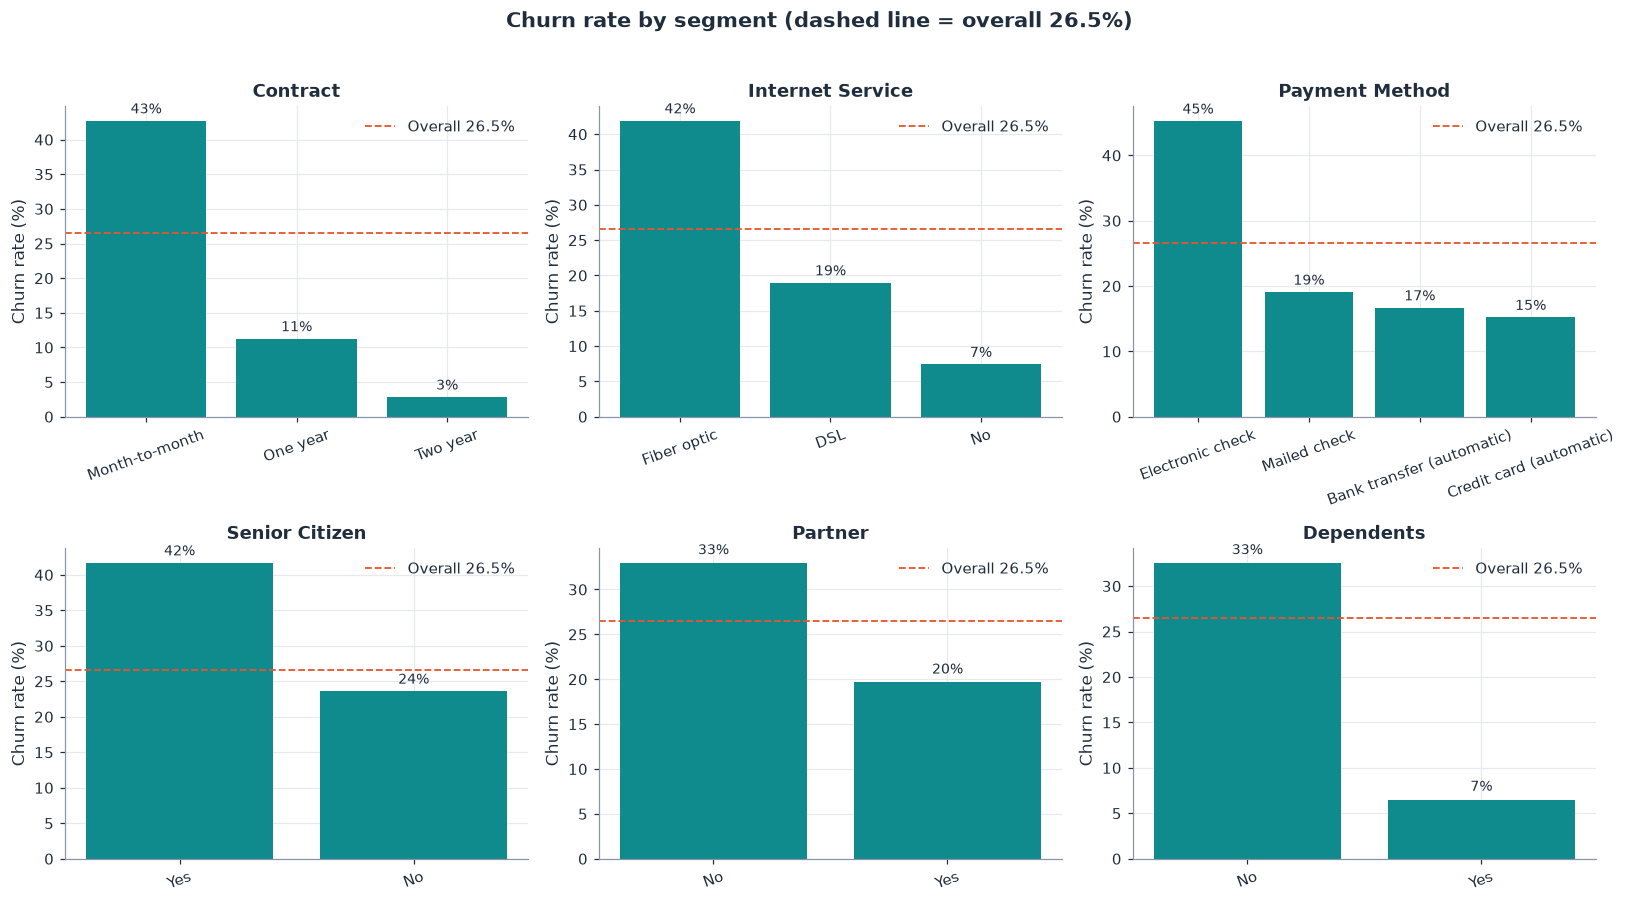

In [7]:
# --- Churn rate across the key categorical drivers ------------------------
drivers = ["Contract", "Internet Service", "Payment Method",
           "Senior Citizen", "Partner", "Dependents"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), drivers):
    viz.churn_rate_by(df, col, ax=ax)
    ax.tick_params(axis="x", rotation=20)
    ax.set_title(col, fontsize=12)
fig.suptitle("Churn rate by segment (dashed line = overall 26.5%)", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

Contract type is the strongest single lever, by a distance. Month-to-month customers churn at around 43%, one-year at 11%, two-year at 3%. Everything below is secondary to that.

- Fibre-optic customers churn far more than DSL or no-internet ones. That reads as a price, expectation or reliability problem worth chasing operationally.
- Electronic-check payers churn two to three times as often as those on automatic methods. Partly friction, and arguably a weaker commitment signal too.
- Senior citizens, and customers without a partner or dependents, churn more. Fewer switching frictions in a single-person household.

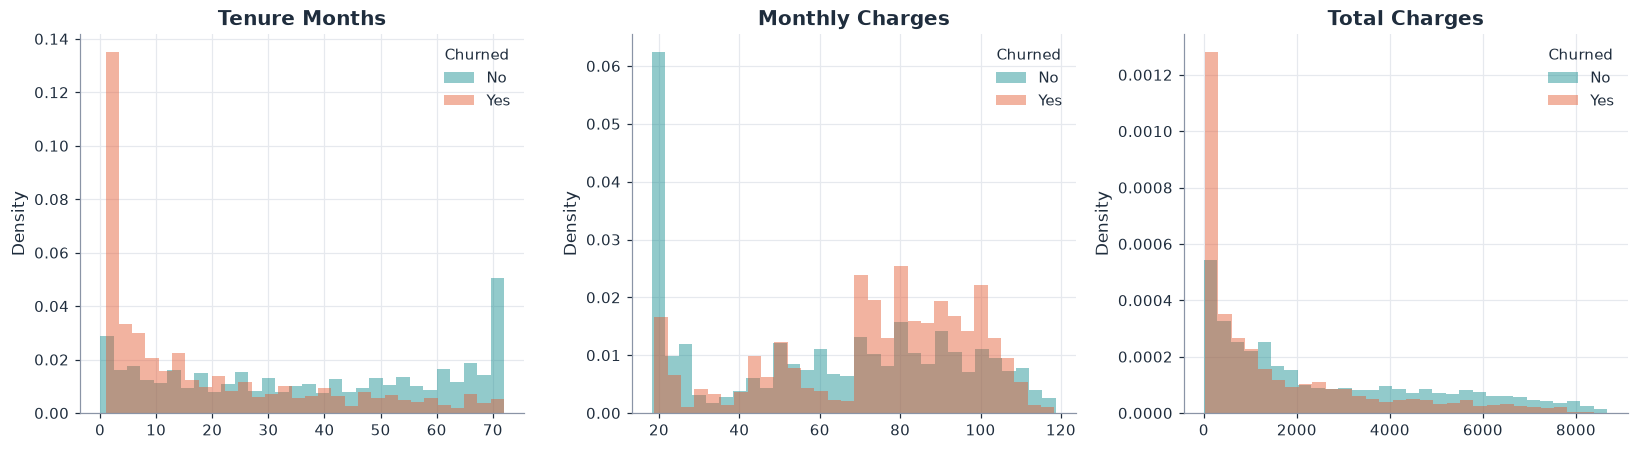

In [8]:
# --- Numeric drivers: how spend and tenure relate to churn ----------------
# Density-normalised histograms (density=True) so the two churn groups are
# comparable despite very different group sizes.
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for a, col in zip(ax, ["Tenure Months", "Monthly Charges", "Total Charges"]):
    for label, g in df.groupby("Churn Label"):
        a.hist(g[col], bins=30, density=True, alpha=0.45,
               color=viz.CHURN_COLORS[1 if label == "Yes" else 0], label=label)
    a.set_title(col); a.set_ylabel("Density"); a.legend(title="Churned")
plt.tight_layout(); plt.show()

Churners cluster at low tenure and high monthly charges, the classic "new and expensive" danger zone. Their low *total* charges are a by-product of short tenure rather than a separate finding. This is what motivates the engineered average monthly spend feature later, which pulls "expensive plan" apart from "short relationship".

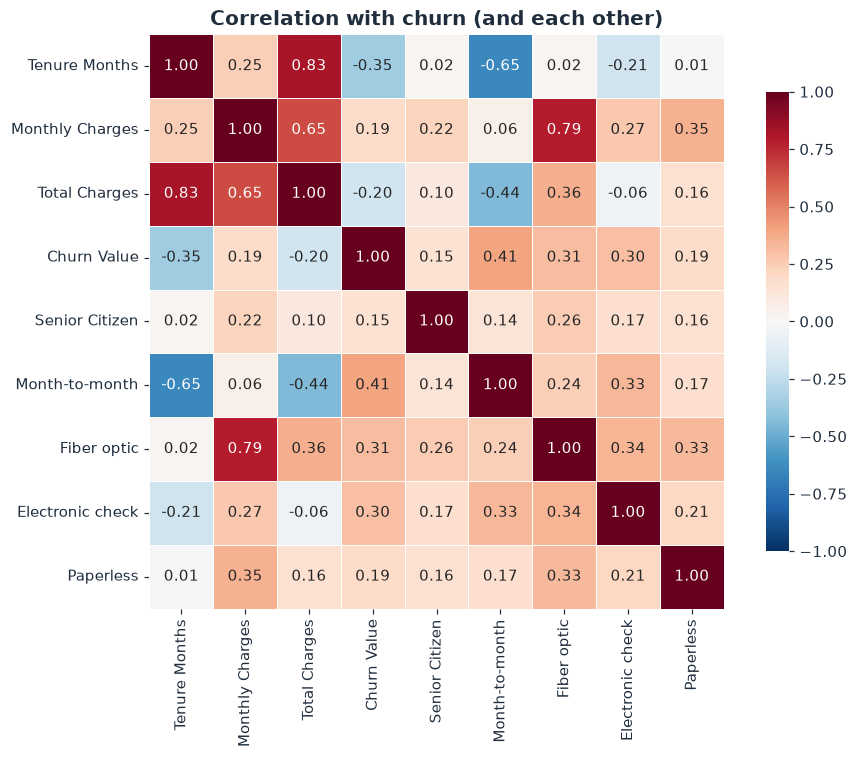

Correlation with Churn Value, ranked:
Month-to-month      0.405
Tenure Months      -0.352
Fiber optic         0.308
Electronic check    0.302
Total Charges      -0.198
Monthly Charges     0.193
Paperless           0.192
Senior Citizen      0.151


In [9]:
# --- Correlation of numeric + binary-encoded features with churn ----------
num = df[["Tenure Months", "Monthly Charges", "Total Charges", config.TARGET]].copy()
# Encode a few high-signal binaries to sit alongside the numerics
num["Senior Citizen"]   = df["Senior Citizen"].eq("Yes").astype(int)
num["Month-to-month"]   = df["Contract"].eq("Month-to-month").astype(int)
num["Fiber optic"]      = df["Internet Service"].eq("Fiber optic").astype(int)
num["Electronic check"] = df["Payment Method"].eq("Electronic check").astype(int)
num["Paperless"]        = df["Paperless Billing"].eq("Yes").astype(int)

corr = num.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation with churn (and each other)")
plt.tight_layout(); plt.show()

print("Correlation with Churn Value, ranked:")
print(corr[config.TARGET].drop(config.TARGET).sort_values(key=np.abs, ascending=False).round(3).to_string())

Tenure is the strongest correlate of churn, negatively. Month-to-month, fibre optic, electronic check, monthly charges and paperless billing all push it the other way. Monthly and total charges are heavily collinear with tenure, which is expected and is part of why tree models suit this problem: they cope with collinearity, and the smoothed spend feature helps as well.

## 4 · Requirement 1 — Who is churning, and why?

This section profiles the 1,869 churners specifically: their demographics, the products they held, and the reasons they gave on the way out.

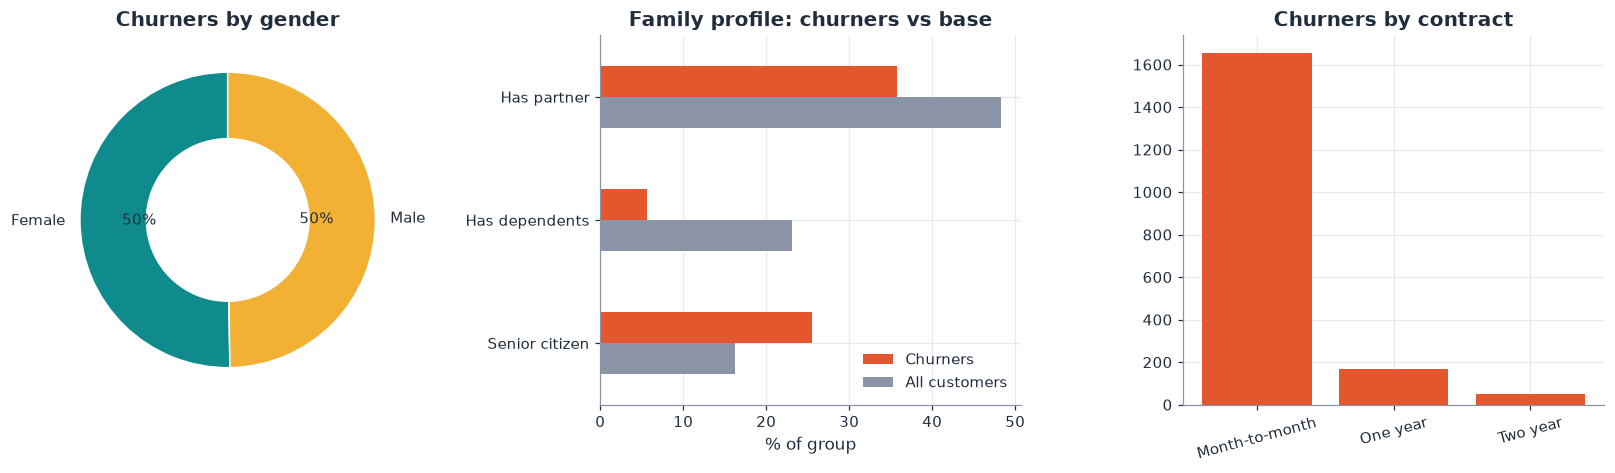

In [10]:
churners = df[df[config.TARGET] == 1]
base = df  # for comparison against the whole base

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
# Gender split of churners
g = churners["Gender"].value_counts()
axes[0].pie(g.values, labels=g.index, autopct="%1.0f%%",
            colors=[viz.SWAN_TEAL, viz.SWAN_GOLD], startangle=90,
            wedgeprops=dict(width=0.45, edgecolor="white"))
axes[0].set_title("Churners by gender")

# Family makeup: share with/without partner & dependents (churners vs base)
fam = pd.DataFrame({
    "Churners": [churners["Partner"].eq("Yes").mean(), churners["Dependents"].eq("Yes").mean(),
                 churners["Senior Citizen"].eq("Yes").mean()],
    "All customers": [base["Partner"].eq("Yes").mean(), base["Dependents"].eq("Yes").mean(),
                      base["Senior Citizen"].eq("Yes").mean()],
}, index=["Has partner", "Has dependents", "Senior citizen"])
fam.mul(100).plot.barh(ax=axes[1], color=[viz.SWAN_CORAL, viz.SWAN_SLATE])
axes[1].set_xlabel("% of group"); axes[1].set_title("Family profile: churners vs base"); axes[1].invert_yaxis()

# Contract mix of churners
c = churners["Contract"].value_counts()
axes[2].bar(c.index, c.values, color=viz.SWAN_CORAL)
axes[2].set_title("Churners by contract"); axes[2].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

Gender splits roughly 50/50, so it is not a driver. Measured against the base, though, churners skew towards senior citizens and away from having a partner or dependents — single-person, lower-commitment households. And they are overwhelmingly month-to-month.

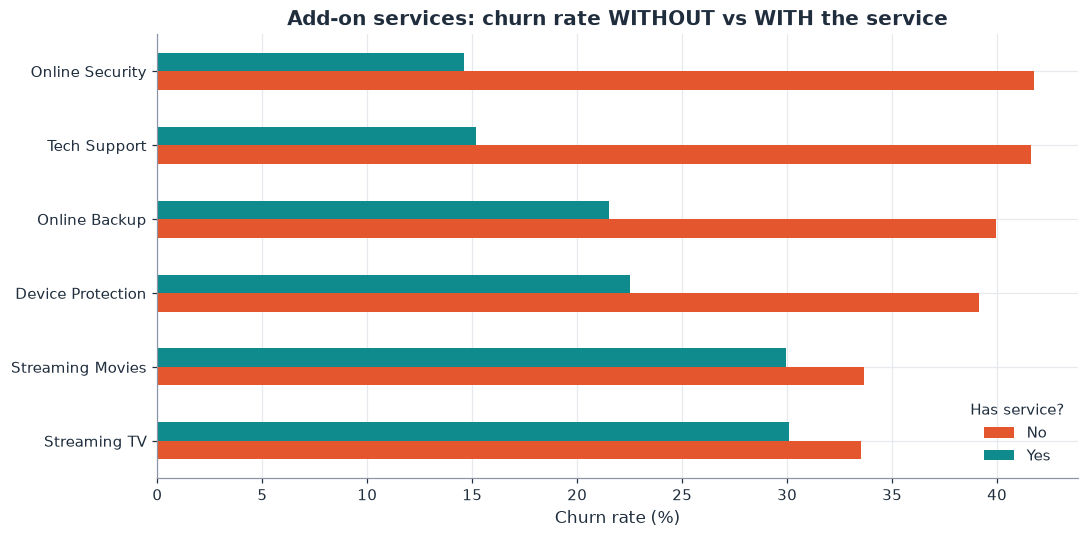

level,No,Yes
service,,
Streaming TV,33.5,30.1
Streaming Movies,33.7,29.9
Device Protection,39.1,22.5
Online Backup,39.9,21.5
Tech Support,41.6,15.2
Online Security,41.8,14.6


In [11]:
# --- What products do churners hold? Churn rate by service ----------------
service_cols = ["Phone Service", "Multiple Lines", "Internet Service"] + config.ADDON_SERVICES
rows = []
for col in service_cols:
    for val, g in df.groupby(col):
        rows.append({"service": col, "level": val, "churn_rate": g[config.TARGET].mean(),
                     "customers": len(g)})
svc = pd.DataFrame(rows)

# Focus on the add-ons held vs not (the actionable ones)
addon = svc[svc["service"].isin(config.ADDON_SERVICES) & svc["level"].isin(["Yes", "No"])]
pivot = addon.pivot(index="service", columns="level", values="churn_rate").mul(100)
pivot = pivot.sort_values("No", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot.barh(ax=ax, color={"No": viz.SWAN_CORAL, "Yes": viz.SWAN_TEAL})
ax.set_xlabel("Churn rate (%)"); ax.set_ylabel("")
ax.set_title("Add-on services: churn rate WITHOUT vs WITH the service")
ax.legend(title="Has service?")
plt.tight_layout(); plt.show()
pivot.round(1)

Customers without the protective add-ons churn dramatically more than those who have them, roughly double for several services, with Online Security and Tech Support showing the widest gaps. These add-ons are probably both a signal of engagement and a cause of stickiness, through sunk cost and perceived value, which makes them the natural target for a sign-up incentive (Section 5). Streaming services show little protective effect; they are entertainment, not lock-in.

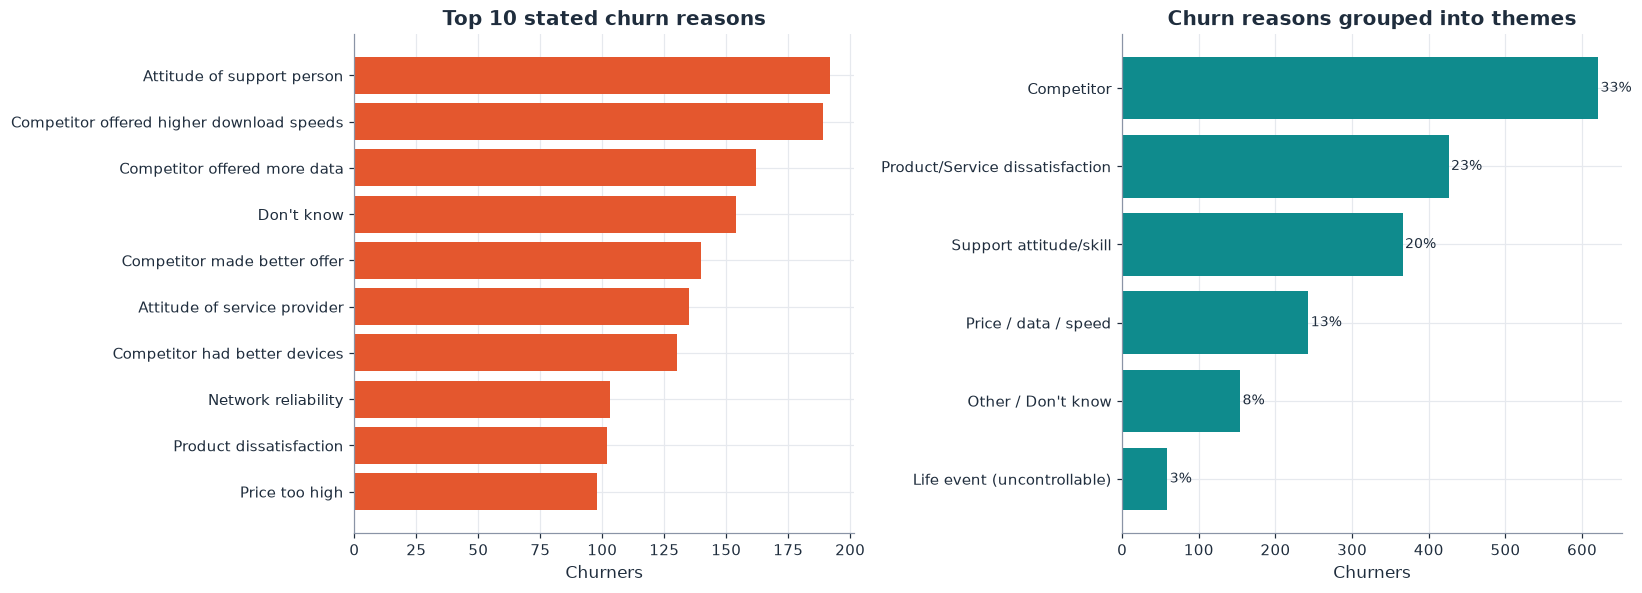

Reasons recorded for 1,869 of 1,869 churners (100%).


In [12]:
# --- WHY are they churning? The Churn Reason column, grouped -------------
def group_reason(reason: str) -> str:
    r = str(reason).lower()
    if "competitor" in r:                              return "Competitor"
    if "attitude" in r or "expertise" in r:            return "Support attitude/skill"
    if "dissatisfaction" in r or "reliability" in r or "self-service" in r or "range of services" in r:
        return "Product/Service dissatisfaction"
    if "price" in r or "charges" in r or "data" in r or "speed" in r:
        return "Price / data / speed"
    if "moved" in r or "deceased" in r:                return "Life event (uncontrollable)"
    return "Other / Don't know"

reasons = churners["Churn Reason"].dropna()
grouped = reasons.map(group_reason).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
# Top individual reasons
top = reasons.value_counts().head(10).sort_values()
axes[0].barh(top.index, top.values, color=viz.SWAN_CORAL)
axes[0].set_title("Top 10 stated churn reasons"); axes[0].set_xlabel("Churners")
# Grouped themes
axes[1].barh(grouped.index[::-1], grouped.values[::-1], color=viz.SWAN_TEAL)
axes[1].set_title("Churn reasons grouped into themes"); axes[1].set_xlabel("Churners")
for i, v in enumerate(grouped.values[::-1]):
    axes[1].text(v+3, i, f"{v/len(reasons):.0%}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

print(f"Reasons recorded for {len(reasons):,} of {len(churners):,} churners "
      f"({reasons.notna().mean():.0%}).")

Competition dominates. Rivals offering better speeds, more data, better devices or simply a better overall package account for the largest share of departures. Support quality comes next, meaning the attitude and expertise of support staff, followed by general product dissatisfaction. A flat "price is too high" appears but does not lead. Customers mostly leave because someone else looked better or because service let them down, and both of those are more addressable than a price war.

## 5 · Requirement 2 — What promotes retention, and what should we incentivise?

Each factor is quantified as the churn-rate gap between having it and not having it. The best of the actionable ones then gets translated into a sign-up incentive, costed against the \$2.50 per metric budget.

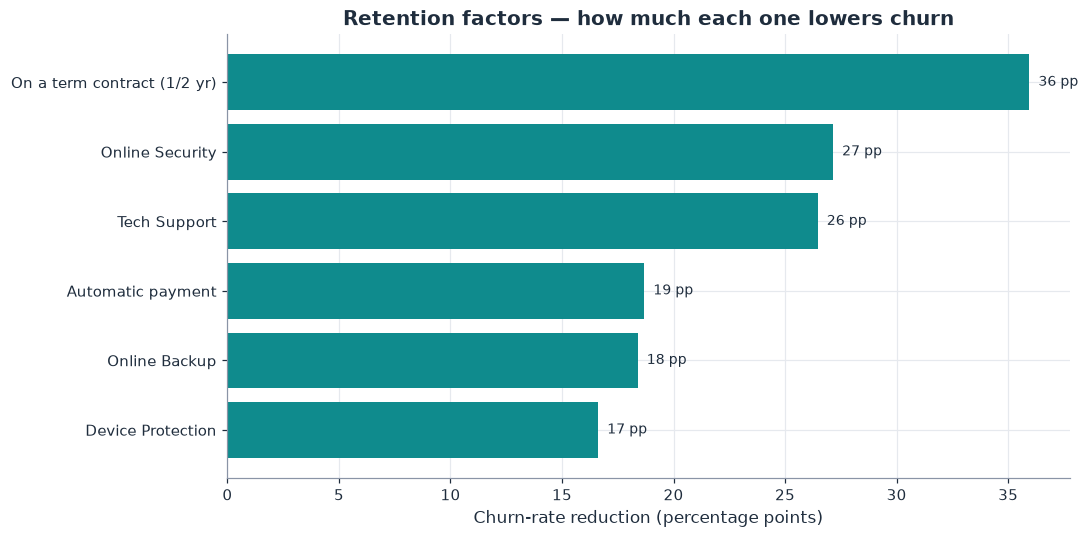

,factor,churn_with,churn_without,customers_without,reduction_pp
0,On a term contract (1/2 yr),6.8,42.7,3875,36.0
1,Online Security,14.6,41.8,3498,27.2
2,Tech Support,15.2,41.6,3473,26.5
3,Automatic payment,16.0,34.7,3977,18.7
4,Online Backup,21.5,39.9,3088,18.4
5,Device Protection,22.5,39.1,3095,16.6


In [13]:
# --- Retention factors: churn-rate reduction for each 'sticky' attribute --
def churn_gap(mask_has, mask_not, name):
    return {"factor": name,
            "churn_with": df.loc[mask_has, config.TARGET].mean(),
            "churn_without": df.loc[mask_not, config.TARGET].mean(),
            "customers_without": int(mask_not.sum())}

internet = df["Internet Service"].ne("No")   # add-ons only meaningful for internet customers
is_auto = df["Payment Method"].str.contains("automatic", case=False)
factors = [
    churn_gap(df["Contract"].ne("Month-to-month"), df["Contract"].eq("Month-to-month"), "On a term contract (1/2 yr)"),
    churn_gap(df["Online Security"].eq("Yes"), internet & df["Online Security"].eq("No"), "Online Security"),
    churn_gap(df["Tech Support"].eq("Yes"),    internet & df["Tech Support"].eq("No"),    "Tech Support"),
    churn_gap(df["Online Backup"].eq("Yes"),   internet & df["Online Backup"].eq("No"),   "Online Backup"),
    churn_gap(df["Device Protection"].eq("Yes"), internet & df["Device Protection"].eq("No"), "Device Protection"),
    churn_gap(is_auto, ~is_auto, "Automatic payment"),
]
ret = pd.DataFrame(factors)
ret["reduction_pp"] = (ret["churn_without"] - ret["churn_with"]) * 100   # percentage points saved
ret = ret.sort_values("reduction_pp", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(ret["factor"][::-1], ret["reduction_pp"][::-1], color=viz.SWAN_TEAL)
ax.set_xlabel("Churn-rate reduction (percentage points)")
ax.set_title("Retention factors — how much each one lowers churn")
for b, v in zip(bars, ret["reduction_pp"][::-1]):
    ax.text(v+0.4, b.get_y()+b.get_height()/2, f"{v:.0f} pp", va="center", fontsize=9)
plt.tight_layout(); plt.show()
ret.assign(churn_with=lambda d: (d.churn_with*100).round(1),
           churn_without=lambda d: (d.churn_without*100).round(1),
           reduction_pp=lambda d: d.reduction_pp.round(1))

### 5.1 The \$2.50 sign-up incentive — recommendation

Incentivise **Online Security** sign-ups first, with **Tech Support** as the second target.

Three reasons. They show the largest churn-rate reduction among the actionable, low-cost add-ons; a term contract beats them both, but that is a commitment ask rather than a \$2.50 giveaway. They are cheap digital services, so covering an introductory period at \$2.50 a customer sits comfortably inside the budget. And they create real lock-in, being the kind of set-and-forget service people rarely get round to cancelling.

On value: churn among internet customers without Online Security runs far higher than among those with it. Even a modest conversion rate at \$2.50 a head pays for itself against the monthly revenue of a single retained customer, which averages about \$65. Section 10 sizes this properly against the model's Top-500 list.

## 6 · Customer segmentation — K-Means archetypes

Sections 4 and 5 asked which individual attributes drive churn. This one asks something different: what recognisable customer types exist, and how do leavers differ from stayers as whole customers rather than one variable at a time?

The method is K-Means, run separately on churners and on retained customers so that each group is described on its own terms. Clustering the base as a single pool would mostly rediscover the churn split we already know about. Binary fields map to 0/1, multi-category fields are one-hot encoded, and the three numeric fields are standardised. Scaling genuinely matters here, unlike for the tree models in Section 8, because K-Means works on Euclidean distance: an unscaled `Total Charges` running into the thousands would drown out everything else in the frame. The choice of `k` comes from reading the elbow and silhouette together, seed 42.

This sits before the modelling because it is descriptive work on the cleaned data. It fills out Requirements 1 and 2 with archetypes, and it hands the retention team a watchlist segment (§6.4) before a single customer has been scored.

### 6.1 Building the segmentation frame

The clustering works on a snake_case, model-free view of the cleaned data: constants, geolocation PII and the leakage columns dropped, column names normalised. It is derived from `df` (Section 2) rather than re-read from the CSV, so the segmentation and the model are looking at identical rows. `df` itself is left alone, and Sections 7 onwards continue exactly as before.

In [14]:
# Segmentation view of the cleaned frame. `df` is NOT modified.
drop_for_segmentation = [
    "Count", "Country", "State",          # constants - zero signal
    "Lat Long", "Latitude", "Longitude",  # geolocation PII
    "Churn Label",                        # duplicate of the target
]
seg = df.drop(columns=[c for c in drop_for_segmentation if c in df.columns]).copy()
seg.columns = [c.replace(" ", "_").lower() for c in seg.columns]

print("Segmentation frame:", seg.shape)
print("Columns:", list(seg.columns))
seg.head()

In [15]:
# Segment the two populations separately (see the note above on why).
churned     = seg[seg["churn_value"] == 1]
non_churned = seg[seg["churn_value"] == 0]
print(f"Churned : {len(churned):,}")
print(f"Retained: {len(non_churned):,}")

In [16]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# --- Feature Preparation ---
def prepare_features(group_df):
    """Encode and scale features for clustering."""
    feat = group_df.drop(columns=['customerid', 'city', 'zip_code', 'churn_value', 'churn_reason']).copy()

    # Convert total_charges to numeric
    feat['total_charges'] = pd.to_numeric(feat['total_charges'], errors='coerce')
    feat['total_charges'] = feat['total_charges'].fillna(0)

    # Binary columns: map Yes/No to 1/0
    binary_cols = ['senior_citizen', 'partner', 'dependents', 'phone_service',
                   'multiple_lines', 'online_security', 'online_backup',
                   'device_protection', 'tech_support', 'streaming_tv',
                   'streaming_movies', 'paperless_billing']

    for col in binary_cols:
        # astype: `data.clean()` returns tightened dtypes, and .map() over a
        # categorical can return a non-numeric Series that KMeans would reject.
        feat[col] = feat[col].map({'Yes': 1, 'No': 0, 'No internet service': 0,
                                   'No phone service': 0}).astype('int64')

    # One-hot encode multi-category columns
    feat = pd.get_dummies(feat, columns=['gender', 'internet_service', 'contract', 'payment_method'], drop_first=True, dtype='int')

    # Scale numeric features
    numeric_cols = ['tenure_months', 'monthly_charges', 'total_charges']
    scaler = StandardScaler()
    feat[numeric_cols] = scaler.fit_transform(feat[numeric_cols])

    return feat

churned_features = prepare_features(churned)
non_churned_features = prepare_features(non_churned)

In [17]:
churned_features.head()

,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,paperless_billing,monthly_charges,total_charges,gender_Male,internet_service_Fiber optic,internet_service_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
0,0,0,0,-0.818356,1,0,1,1,0,0,0,0,1,-0.835028,-0.753126,1,0,0,0,0,0,0,1
1,0,0,1,-0.818356,1,0,0,0,0,0,0,0,1,-0.151720,-0.730114,0,1,0,0,0,0,1,0
2,0,0,1,-0.511072,1,1,0,0,1,0,1,1,1,1.022272,-0.376284,0,1,0,0,0,0,1,0
3,0,1,1,0.513209,1,1,0,0,1,1,1,1,1,1.231117,0.801058,0,1,0,0,0,0,1,0
4,0,0,1,1.588704,1,1,0,1,1,0,1,1,1,1.186509,1.853924,1,1,0,0,0,0,0,0


In [18]:
non_churned_features.head()

,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,paperless_billing,monthly_charges,total_charges,gender_Male,internet_service_Fiber optic,internet_service_No,contract_One year,contract_Two year,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check
1869,0,1,0,-1.516706,0,0,0,1,0,0,0,0,1,-1.010469,-1.081697,0,0,0,0,0,0,1,0
1870,0,0,0,-0.148061,1,0,1,0,1,0,0,0,0,-0.138796,-0.283471,1,0,0,1,0,0,0,1
1871,0,0,0,0.308154,0,0,1,0,1,1,0,0,0,-0.610014,-0.304397,1,0,0,1,0,0,0,0
1872,0,0,1,-0.645750,1,1,0,1,0,0,1,0,1,0.895310,-0.257760,1,1,0,0,0,1,0,0
1873,0,0,0,-1.143439,0,0,1,0,0,0,0,0,0,-1.013686,-0.964924,0,0,0,0,0,0,0,1


### 6.2 Choosing `k`

Elbow and silhouette get read together. The elbow shows where extra clusters stop buying much compaction; the silhouette shows whether the clusters are actually separated from each other. Both point to k = 3 for churners and k = 4 for retained customers.

In [19]:
# --- Find Optimal k (Elbow + Silhouette) ---
def find_optimal_k(features, k_range=range(2, 9)):
    inertias = []
    silhouettes = []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(features)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(features, labels))
    return list(k_range), inertias, silhouettes

# Evaluate for churned customers
k_vals_churned, inertias_c_churned, silhouettes_c_churned = find_optimal_k(churned_features)

# Evaluate for non-churned customers
k_vals_retained, inertias_c_retained, silhouettes_c_retained = find_optimal_k(non_churned_features)

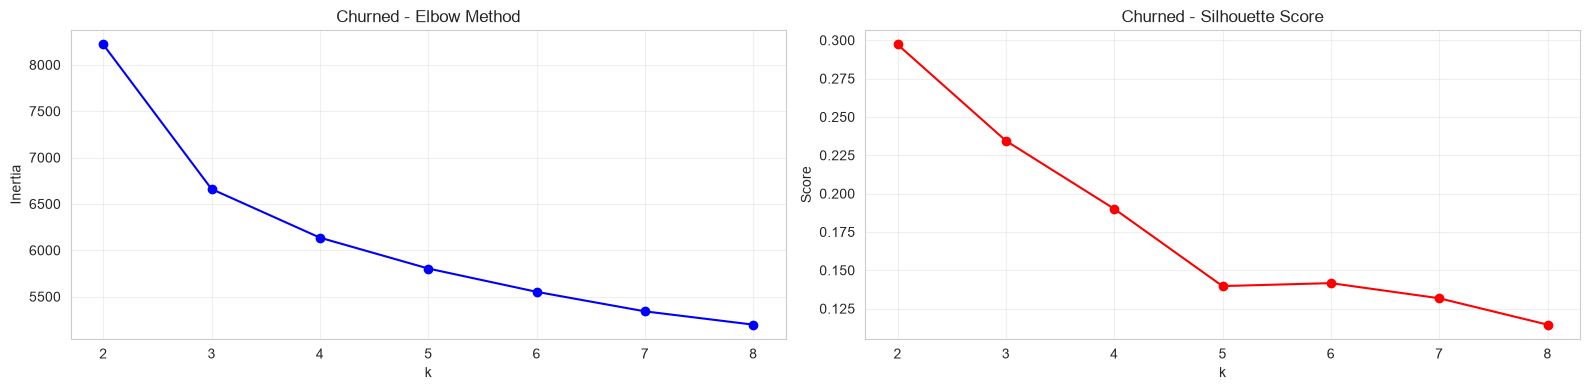

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(k_vals_churned, inertias_c_churned, 'bo-')
axes[0].set_title('Churned - Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(k_vals_churned, silhouettes_c_churned, 'ro-')
axes[1].set_title('Churned - Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

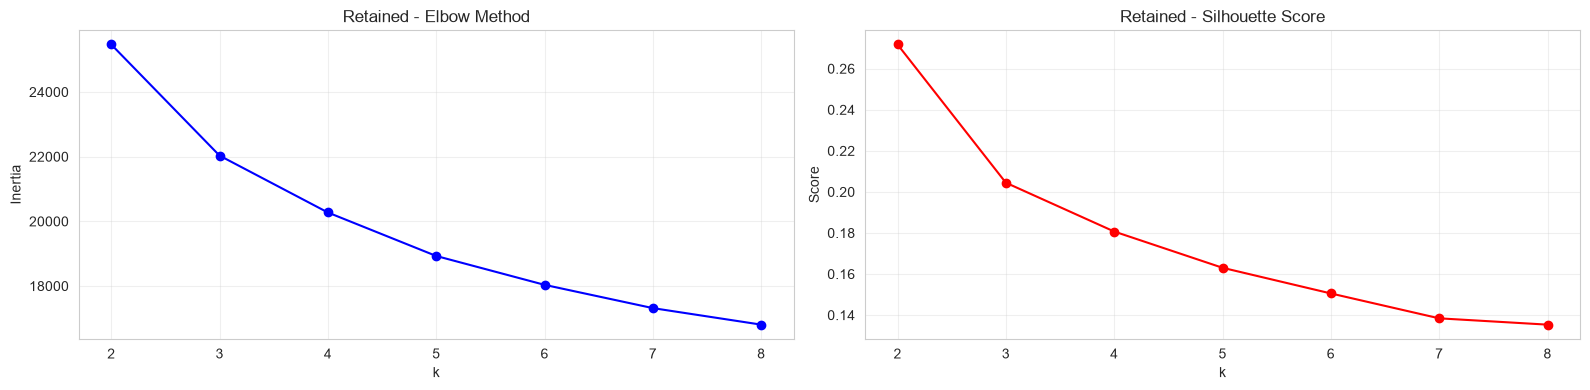

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
axes[0].plot(k_vals_retained, inertias_c_retained, 'bo-')
axes[0].set_title('Retained - Elbow Method')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(k_vals_retained, silhouettes_c_retained, 'ro-')
axes[1].set_title('Retained - Silhouette Score')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# --- Fit Final Clusters ---
k_churned = 3  # adjust based on elbow/silhouette plots
km_churned = KMeans(n_clusters=k_churned, random_state=42, n_init=10)
churned_labels = km_churned.fit_predict(churned_features) + 1

k_non_churned = 4
km_non_churned = KMeans(n_clusters=k_non_churned, random_state=42, n_init=10)
non_churned_labels = km_non_churned.fit_predict(non_churned_features) + 1

# --- Profile Clusters ---
churned_profiled = churned.copy()
churned_profiled['cluster'] = churned_labels

non_churned_profiled = non_churned.copy()
non_churned_profiled['cluster'] = non_churned_labels

churned_profiled.head()


,customerid,city,zip_code,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_reason,cluster
0,3668-QPYBK,Los Angeles,90003,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,Competitor made better offer,1
1,9237-HQITU,Los Angeles,90005,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,Moved,3
2,9305-CDSKC,Los Angeles,90006,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,Moved,3
3,7892-POOKP,Los Angeles,90010,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,Moved,2
4,0280-XJGEX,Los Angeles,90015,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,Competitor had better devices,2


In [23]:
churned_profiled.info()

<class 'pandas.DataFrame'>
RangeIndex: 1869 entries, 0 to 1868
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customerid         1869 non-null   str    
 1   city               1869 non-null   str    
 2   zip_code           1869 non-null   int64  
 3   gender             1869 non-null   str    
 4   senior_citizen     1869 non-null   str    
 5   partner            1869 non-null   str    
 6   dependents         1869 non-null   str    
 7   tenure_months      1869 non-null   int64  
 8   phone_service      1869 non-null   str    
 9   multiple_lines     1869 non-null   str    
 10  internet_service   1869 non-null   str    
 11  online_security    1869 non-null   str    
 12  online_backup      1869 non-null   str    
 13  device_protection  1869 non-null   str    
 14  tech_support       1869 non-null   str    
 15  streaming_tv       1869 non-null   str    
 16  streaming_movies   1869 non-null   

In [24]:
non_churned_profiled.head()

,customerid,city,zip_code,gender,senior_citizen,partner,dependents,tenure_months,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn_value,churn_reason,cluster
1869,7590-VHVEG,Los Angeles,90001,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,NaN,4
1870,5575-GNVDE,Los Angeles,90002,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,NaN,1
1871,7795-CFOCW,Los Angeles,90004,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,NaN,1
1872,1452-KIOVK,Los Angeles,90007,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,0,NaN,1
1873,6713-OKOMC,Los Angeles,90008,Female,No,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,0,NaN,4


### 6.3 Churned cluster interpretation

#### Distribution

In [25]:
def cluster_distribution(profiled_df):
    """
    Show the number and percentage of customers in each cluster.
    Uses seaborn countplot and a styled pie chart.
    Returns a summary DataFrame.
    """
    # 4 colours, sliced to the cluster count: this helper is called on the
    # retained group too, which has 4 clusters - a 3-colour list silently
    # cycled and gave clusters 1 and 4 the same colour.
    palette = ['#2c587e', '#a47147', '#d15115', '#dac3b4'][:profiled_df['cluster'].nunique()]

    dist = profiled_df['cluster'].value_counts().sort_index()
    dist_pct = profiled_df['cluster'].value_counts(normalize=True).sort_index() * 100

    summary = pd.DataFrame({
        'count': dist,
        'percentage': dist_pct.round(2)
    })
    summary.index.name = 'cluster'

    # Set seaborn style for clean visuals
    sns.set_style('whitegrid')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Countplot (left) ---
    sns.countplot(
        x='cluster',
        data=profiled_df,
        order=sorted(profiled_df['cluster'].unique()),
        palette=palette,
        ax=axes[0],
        edgecolor='black',
        linewidth=0.8
    )
    axes[0].set_title(f'Customer Count by Cluster', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Cluster', fontsize=11)
    axes[0].set_ylabel('Count', fontsize=11)

    # Add count labels on top of each bar
    for container in axes[0].containers:
        axes[0].bar_label(container, fontsize=10, padding=3)

    # --- Pie chart (right) ---
    n_clusters = len(summary)
    # Cycle through the palette if more clusters than colors
    pie_colors = [palette[i % len(palette)] for i in range(n_clusters)]

    wedges, texts, autotexts = axes[1].pie(
        summary['percentage'],
        labels=[f'Cluster {i}' for i in summary.index],
        autopct='%1.1f%%',
        startangle=90,
        colors=pie_colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 10}
    )
    # Style the percentage text
    for autotext in autotexts:
        autotext.set_fontweight('bold')
        autotext.set_color('white')

    axes[1].set_title(f'Cluster Proportion', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return summary

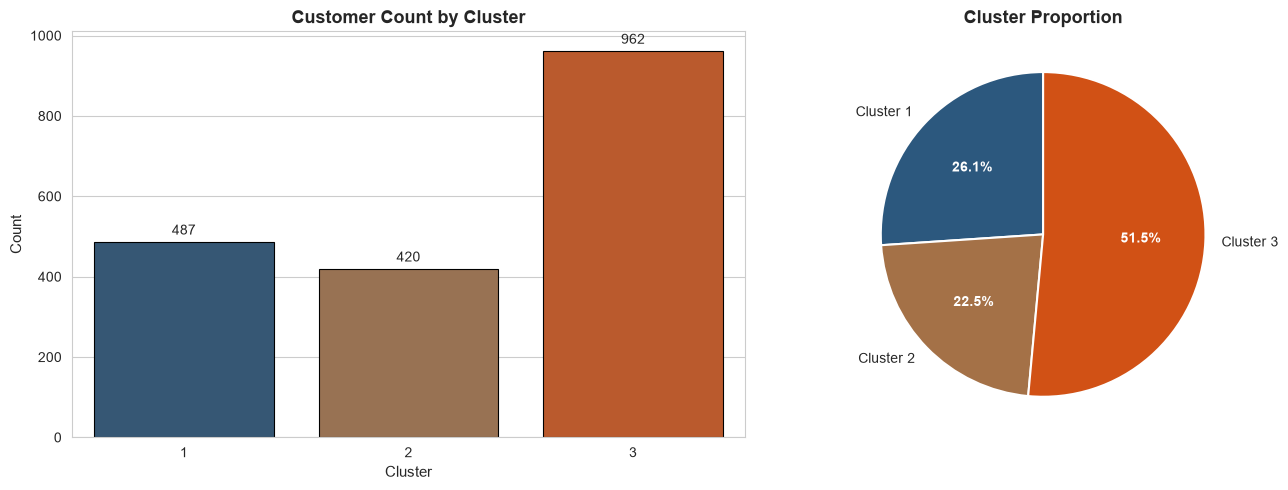

,count,percentage
cluster,,
1,487,26.06
2,420,22.47
3,962,51.47


In [26]:
cluster_distribution(churned_profiled)

#### Numeric features

In [27]:
def numeric_profile_by_cluster(profiled_df):
    """
    Compute and visualize the mean of each numeric feature per cluster.
    Produces a figure with 3 subplots (one per numeric feature) using seaborn barplots.
    Returns the aggregated DataFrame.
    """
    # 4 colours, sliced to the cluster count: this helper is called on the
    # retained group too, which has 4 clusters - a 3-colour list silently
    # cycled and gave clusters 1 and 4 the same colour.
    palette = ['#2c587e', '#a47147', '#d15115', '#dac3b4'][:profiled_df['cluster'].nunique()]

    # Ensure total_charges is numeric
    df_temp = profiled_df.copy()
    df_temp['total_charges'] = pd.to_numeric(df_temp['total_charges'], errors='coerce').fillna(0)

    numeric_cols = ['tenure_months', 'monthly_charges', 'total_charges']
    agg = df_temp.groupby('cluster')[numeric_cols].mean().round(2)

    # Set seaborn style
    sns.set_style('whitegrid')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for idx, col in enumerate(numeric_cols):
        sns.barplot(
            x='cluster',
            y=col,
            data=df_temp,
            estimator='mean',
            errorbar=None,
            order=sorted(df_temp['cluster'].unique()),
            palette=palette,
            ax=axes[idx],
            edgecolor='black',
            linewidth=0.8
        )

        # Format title nicely
        col_title = col.replace('_', ' ').title()
        axes[idx].set_title(f'{col_title}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Cluster', fontsize=10)
        axes[idx].set_ylabel(f'Average {col_title}', fontsize=10)

        # Add value labels on top of each bar
        for container in axes[idx].containers:
            axes[idx].bar_label(container, fmt='%.1f', fontsize=9, padding=3)

    plt.suptitle(f'Average Numeric Features by Cluster', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return agg

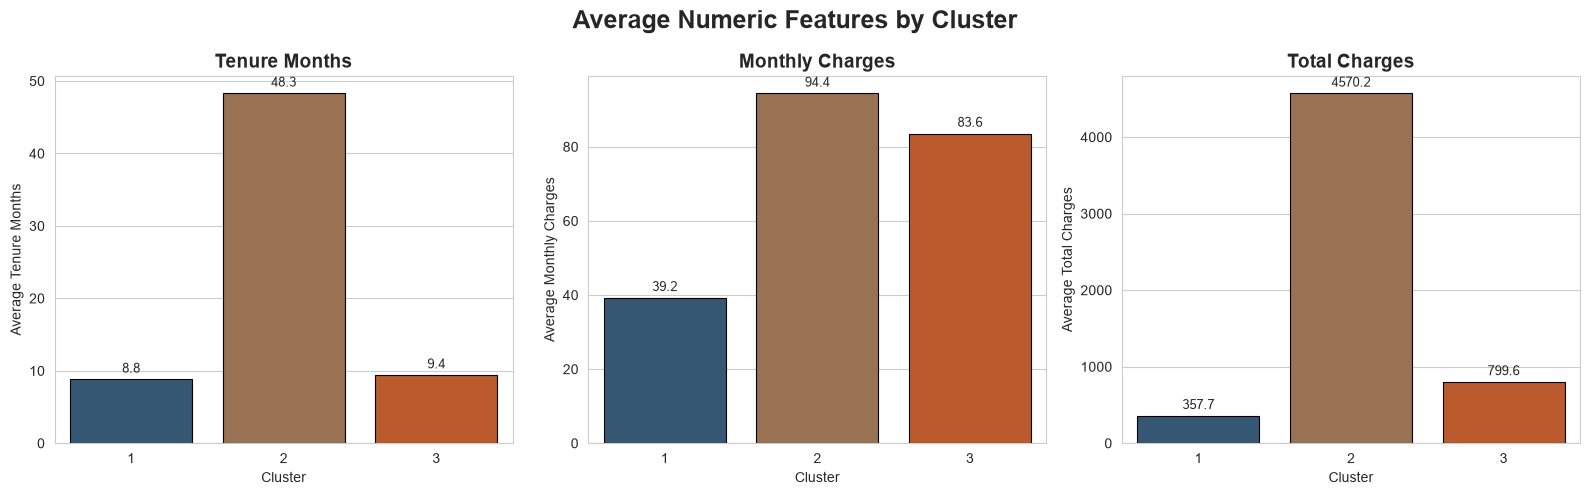

,tenure_months,monthly_charges,total_charges
cluster,,,
1,8.80,39.23,357.67
2,48.29,94.39,4570.20
3,9.39,83.56,799.65


In [28]:
numeric_profile_by_cluster(churned_profiled)

#### Categorical features

In [29]:
def categorical_profile_by_cluster(profiled_df):
    """
    For each key categorical feature, compute the percentage distribution
    within each cluster and visualize with seaborn barplots.
    Clusters are on the x-axis; category values are denoted by color (hue).
    Y-axes are fixed to 0-100%.
    Returns a dict of cross-tab DataFrames keyed by column name.
    """
    palette = ['#2c587e', '#a47147', '#d15115', '#dac3b4']

    cat_cols = ['gender', 'senior_citizen', 'partner', 'dependents',
                'phone_service', 'multiple_lines', 'internet_service',
                'online_security', 'online_backup', 'device_protection',
                'tech_support', 'streaming_tv', 'streaming_movies',
                'contract', 'paperless_billing', 'payment_method']

    cross_tabs = {}

    for col in cat_cols:
        ct = pd.crosstab(profiled_df['cluster'], profiled_df[col], normalize='index') * 100
        cross_tabs[col] = ct

    # Set seaborn style
    sns.set_style('whitegrid')

    n_cols_plot = 2
    n_rows_plot = (len(cat_cols) + n_cols_plot - 1) // n_cols_plot
    fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(16, 5.5 * n_rows_plot))
    axes = axes.flatten()

    for idx, col in enumerate(cat_cols):
        # Melt the cross-tab into long format for seaborn
        ct = cross_tabs[col].copy()
        ct.index.name = 'cluster'
        ct_long = ct.reset_index().melt(id_vars='cluster', var_name=col, value_name='percentage')
        ct_long['cluster'] = ct_long['cluster'].astype(str)

        # Clusters on x-axis, category values as hue (color)
        sns.barplot(
            x='cluster',
            y='percentage',
            hue=col,
            data=ct_long,
            palette=palette[:len(ct.columns)],
            ax=axes[idx],
            edgecolor='black',
            linewidth=0.6
        )

        col_title = col.replace('_', ' ').title()
        axes[idx].set_title(f'{col_title}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Cluster', fontsize=9)
        axes[idx].set_ylabel('Percentage (%)', fontsize=9)
        axes[idx].set_ylim(0, 100)
        axes[idx].legend(title=col_title, fontsize=7, title_fontsize=8, loc='upper right')

    # Hide unused subplots
    for idx in range(len(cat_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle(f'Categorical Feature Distribution by Cluster',
                 fontsize=18, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    # return cross_tabs

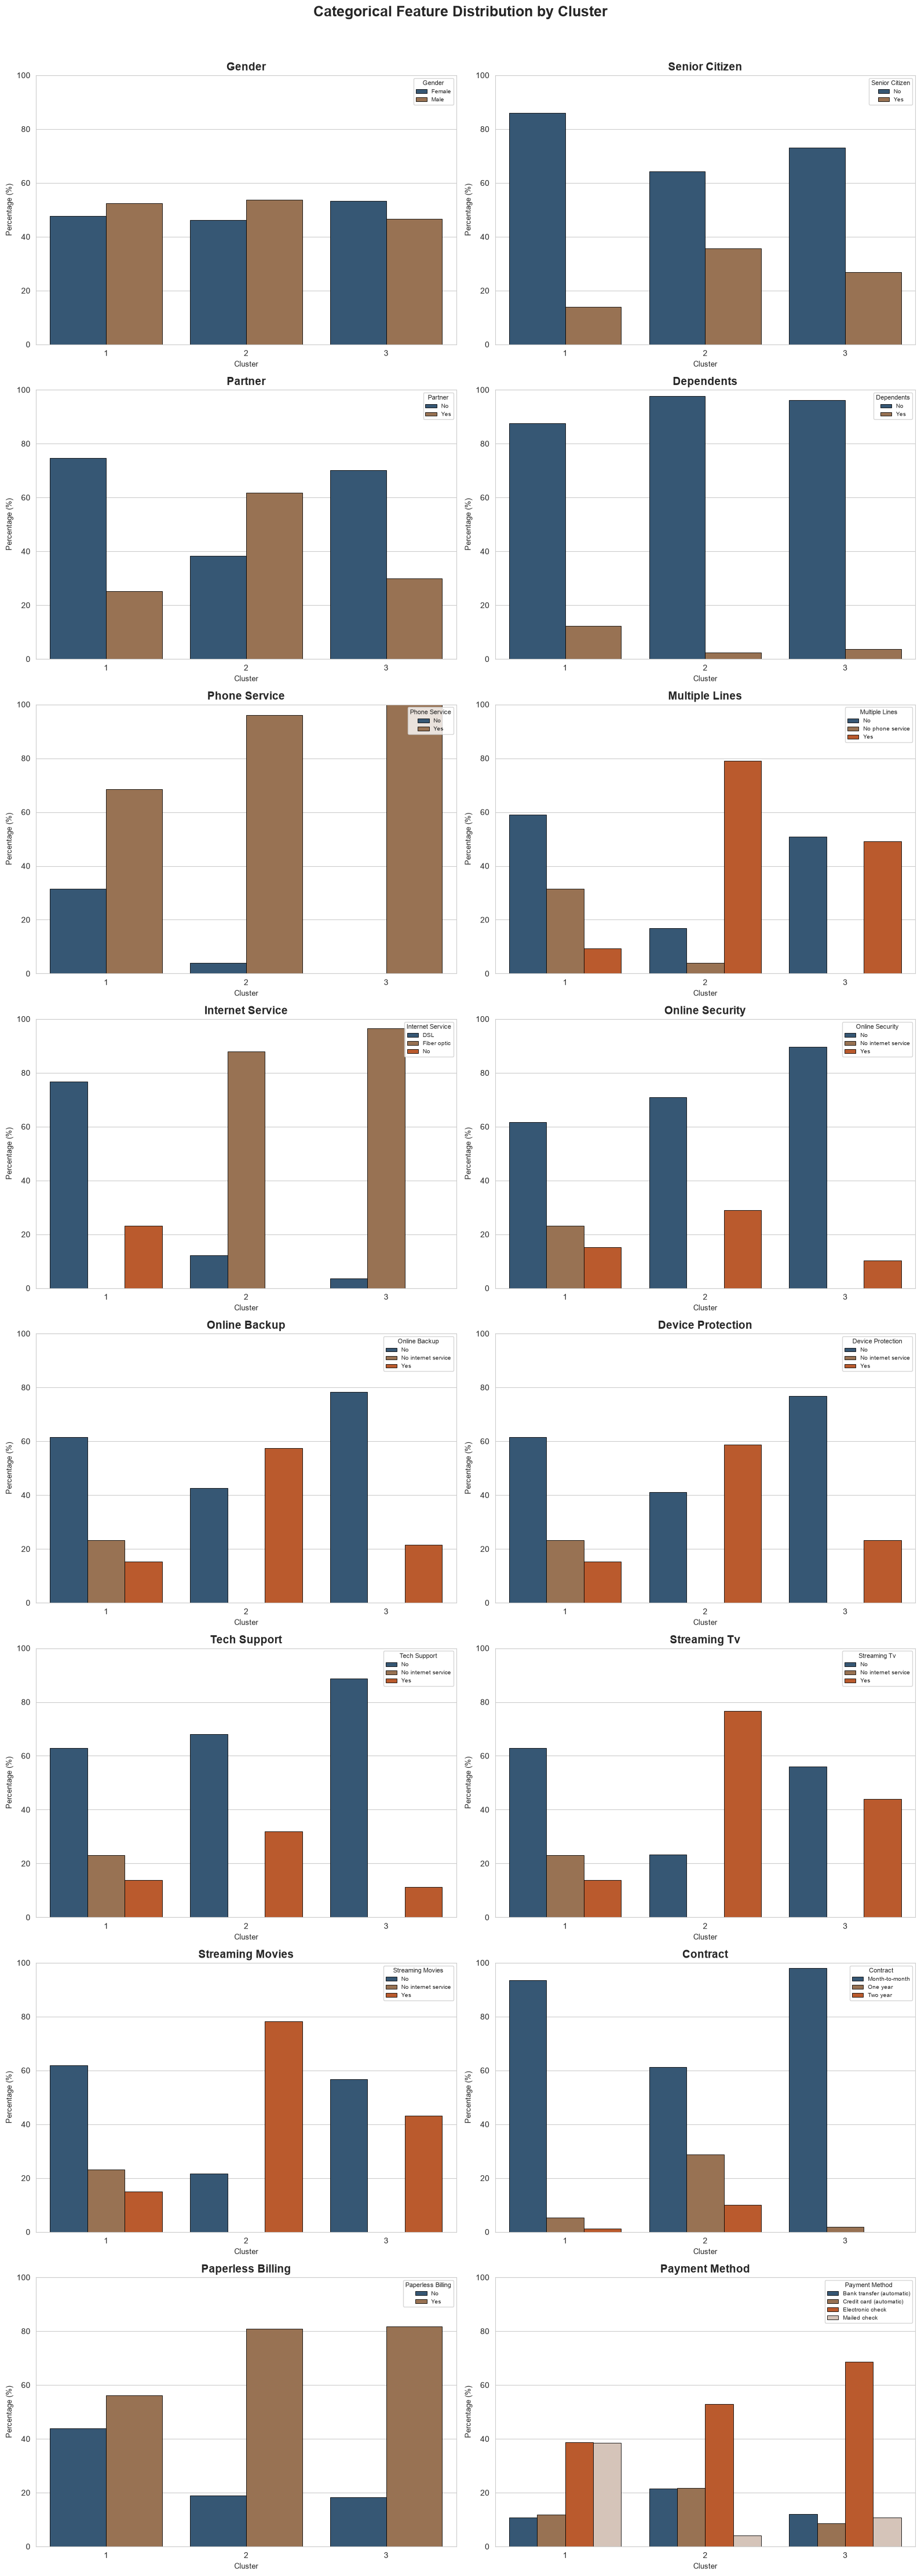

In [30]:
categorical_profile_by_cluster(churned_profiled)

#### Churned customers — cluster profiles

The churned group splits into three clusters:

| Feature |	Cluster 1 |	Cluster 2 |	Cluster 3 |
|---------|-----------|-----------|-----------|
| Number of Customers | 487 (26.1%) | 420 (22.5%) | 962 (51.5%) |
| Avg Tenure (months) |	Low (~9 months) |	Moderate-Long (~4 years) |	Low (~9 months) |
| Avg Monthly Charges |	Low-medium (\$39.20)	| High (\$94.40) |	High (\$83.60)|
| Avg Total Charges |	Low (\$357.70)	| Higher (\$4,570.20)	| Low-medium (\$799.60) |
| Internet Service |	Mostly DSL / No internet |	Overwhelmingly Fiber optic |	Overwhelmingly Fiber optic |
| Contract |	~93% Month-to-month |	~61% Month-to-month |	~98% Month-to-month |
| Payment Method |	Split between Electronic check & Mailed check	 | ~53% Electronic check |	~69% Electronic check |
| Online Security / Tech Support |	~61% "No" (rest either have it or no internet) |	~70% "No" |	~89-90% "No" |
| Paperless Billing	| ~56% Yes |	~81% Yes |	~82% Yes |
| Senior Citizen |	~14% Yes |	~36% Yes |	~27% Yes |
| Partner / Dependents |	Low partner rate; low dependents |	Higher partner rate; very low dependents |	Low partner; very low dependents |

**What the three churner types look like**

Cluster 3 is the at-risk archetype, and the largest of the three at just over half of all leavers: very short tenure, very high monthly charges, almost entirely month-to-month, fibre optic, paying by electronic check, and holding virtually none of the value-added services. High revenue, low loyalty.

Cluster 2 shares a lot with Cluster 3 — fibre, high charges, paperless billing, electronic check — but with noticeably longer tenure at around four years, and more add-ons. These look like customers who gave the service a proper run and left anyway.

Cluster 1 is a different animal. Lower monthly charges, more DSL or no internet at all, more mailed-check payments, still heavily month-to-month. This group leaves despite lighter engagement with the add-ons, which points at price sensitivity on the basic services rather than disappointment with the extras.

### 6.4 Comparison with retained customers

In [31]:
cluster_distribution(non_churned_profiled)

In [32]:
numeric_profile_by_cluster(non_churned_profiled)

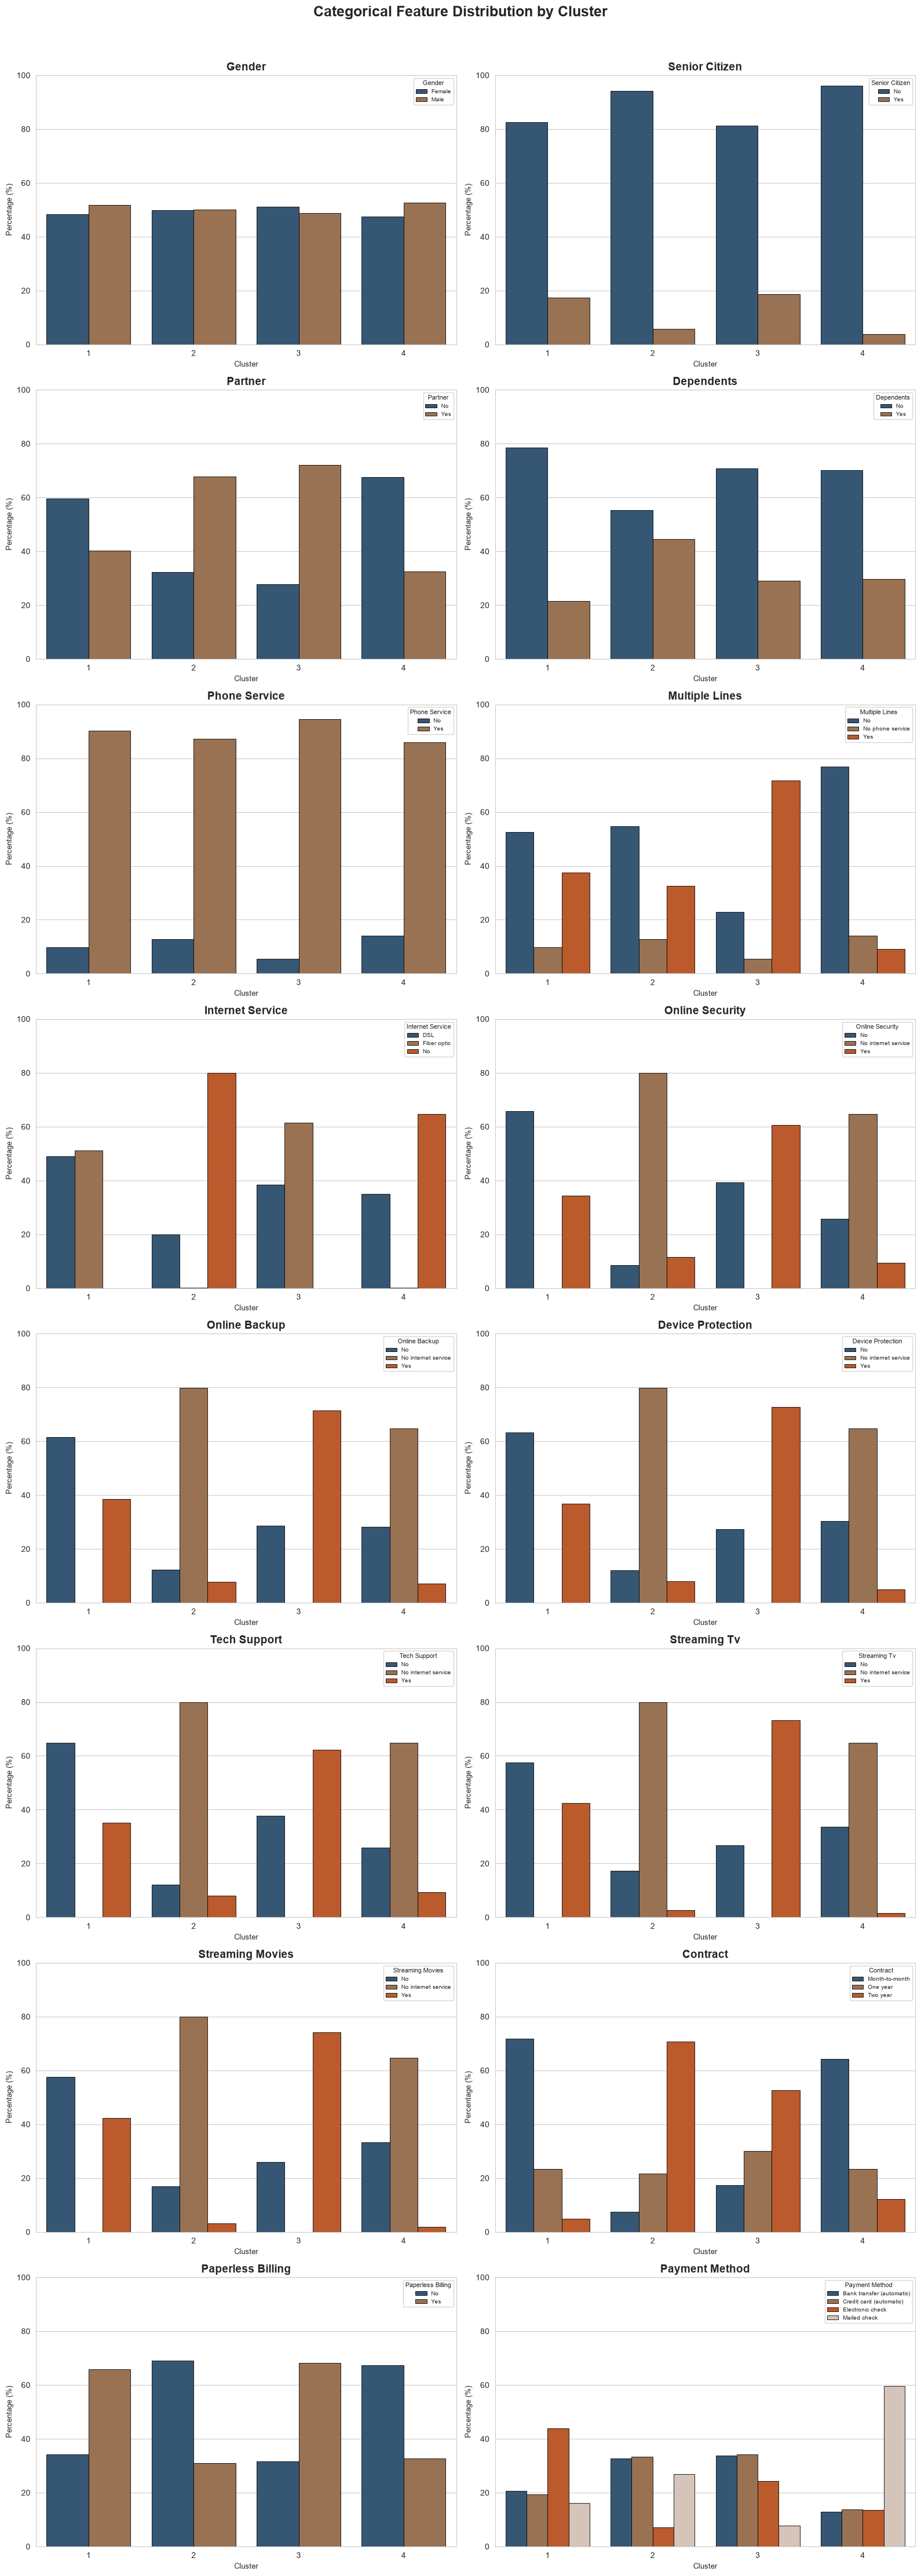

In [33]:
categorical_profile_by_cluster(non_churned_profiled)

#### Retained customers — cluster profiles

The retained group splits into four:

| Feature | Cluster 1 | Cluster 2 | Cluster 3 | Cluster 4 |
|---------|-----------|-----------|-----------|-----------|
| Number of Customers | 1551 (30.0%) | 805 (15.6%) | 1629 (31.5%) | 1189 (23.0%) |
| Avg Tenure (months) | Medium (~23 months) | Long (~56 months) | Long (~61 months) | Short (~12 months) |
| Avg Monthly Charges | High (\$73.40) | Low (\$26.40) | High (\$90.90) | Low (\$28.30) |
| Avg Total Charges | Medium (\$1,644.60) | Medium (\$1,478.70) | High (\$5,573.00) | Low (\$314.40) |
| Internet Service | ~49% DSL / ~51% Fiber optic | ~80% No internet | ~38% DSL / ~62% Fiber optic | ~35% DSL / ~65% No internet |
| Contract | ~72% Month-to-month | ~71% Two year | ~52% Two year / ~30% One year | ~64% Month-to-month |
| Payment Method | ~44% Electronic check | ~33% Credit card / ~33% Bank transfer | ~34% Credit card / ~34% Bank transfer | ~60% Mailed check |
| Online Security / Tech Support | ~65% "No" | ~80% "No internet service" | ~39–38% "No" / 60–62% "Yes" | ~26% "No" / ~65% "No internet service" |
| Paperless Billing | ~66% Yes | ~31% Yes | ~68% Yes | ~33% Yes |
| Senior Citizen | ~17% Yes | ~6% Yes | ~19% Yes | ~4% Yes |
| Partner / Dependents | ~40% partner; ~22% dependents | ~68% partner; ~45% dependents | ~72% partner; ~29% dependents | ~32% partner; ~30% dependents |

**What the four retained types look like**

Cluster 3 is the ideal customer: around five years of tenure, very high monthly charges, overwhelmingly on one- or two-year contracts, heavy adoption of add-ons across the board, paying automatically by bank transfer or card. High value and high loyalty at the same time.

Cluster 2 is loyal but low-engagement. Long tenure, very low monthly charges, mostly no internet service, largely two-year contracts, automatic payment. Most likely phone-only customers on long-term plans who never took up the digital services.

Cluster 1 is the risk segment hiding inside the retained base: medium tenure at about 23 months, high charges across a mix of fibre and DSL, mostly month-to-month, heavy electronic-check use, and low add-on adoption. The profile mirrors churned Cluster 3 closely enough to treat these customers as future churn candidates.

Cluster 4 is the recently-acquired, low-engagement group: about a year in, low charges, mostly no internet, mailed check, mostly month-to-month. They have not left, but short tenure with no contract lock-in makes them vulnerable.

### 6.5 What the segmentation adds

Five things stand out once the archetypes sit side by side.

1. **Month-to-month is the strongest churn signal.** Every churned cluster runs 93-98% month-to-month, while the most loyal retained cluster is predominantly on fixed terms, around 52% two-year and 30% one-year. The retained risk segment that mirrors the churners sits at ~72% month-to-month.

2. **Fibre optic, high charges and low tenure together are the dangerous combination.** Churned Clusters 2 and 3, which are 74% of all leavers, are overwhelmingly fibre with high monthly charges. Retained Cluster 3 has the same fibre-and-high-charges profile, and what separates them is tenure — five years against nine months — plus heavy add-on adoption. Fibre customers on high prices seem to stay only when they are also locked in and using the extras.

3. **Missing add-ons track closely with churn.** Churned clusters run 61-90% "No" on online security and tech support, while the most stable retained cluster runs 60-62% "Yes". Low engagement with these services goes hand in hand with disengagement more generally.

4. **Electronic check is overrepresented among leavers.** Churned Clusters 2 and 3 lean heavily on it at 53-69%, while the loyal retained clusters favour automatic methods, credit card and bank transfer at roughly 33-34% each. Manual payment may be a proxy for lower commitment, or simply more opportunities each month for friction to end the relationship.

5. **Short tenure on its own is not the risk; short tenure with the wrong mix is.** Retained Cluster 4 has tenure as short as the churned clusters but stays put on low charges and no-internet, mailed-check patterns. It is pairing short tenure with fibre pricing and month-to-month terms that looks dangerous.

The practical takeaway is retained Cluster 1. Mid tenure, high charges, month-to-month, electronic check, low add-on adoption — close enough to the worst churned archetype to make it the most actionable group in the retained base, and worth a proactive campaign before the model scores anyone.

## 7 · Feature engineering

The design lives in `swan.features`; the reasoning and the trade-offs are argued here.

**Features added:**

| Feature | Definition | Why |
|---|---|---|
| `Num Addon Services` | count of the 6 add-ons held | one clean "stickiness" signal instead of 6 scattered flags |
| `Avg Monthly Spend` | Total ÷ Tenure (guarded) | separates *expensive plan* from *short relationship* |
| `Tenure Group` | 0–12 / 13–24 / 25–48 / 49+ | non-linear life-stage effect, and readable |
| `Has Internet` | internet ≠ "No" | collapses the "No internet service" noise |
| `Auto Payment` | automatic vs manual | manual payers churn far more |
| `New Customer` | tenure ≤ 6 months | isolates the highest-risk window |

**On encoding.** Categoricals are one-hot encoded throughout. With tree ensembles that is safe, and it keeps every category legible in the feature-importance output later on. Ordinal encoding would impose a false order on genuinely nominal fields like Payment Method.

Numerics are not scaled by default. All four candidate models are tree-based and therefore scale-invariant, so standardising would cost time and blur importances for no benefit. Rather than just assert that, there is a `scale_numeric` flag and a check below confirming that toggling it leaves the tree results unchanged. Section 6 is the counter-example: K-Means needs the scaling, and gets it.

The encoder runs with `handle_unknown="ignore"`, so a new category in a future data refresh degrades gracefully instead of crashing the scoring product.

In [34]:
# Add engineered features and assemble the modelling matrix. PII, constant and
# leakage columns are excluded *by construction* inside swan.features.
df = features.engineer(df)
X, y = features.build_feature_frame(df, use_engineered=True)

print("Modelling matrix X:", X.shape, "| target churn rate:", f"{y.mean():.1%}")
print("\nNumeric features    :", features.feature_columns()[0])
print("Categorical features:", features.feature_columns()[1])

# Sanity: prove no PII / leakage leaked into X
forbidden = set(config.PII_COLUMNS) | set(config.LEAKAGE_COLUMNS) | set(config.CONSTANT_COLUMNS)
assert not (set(X.columns) & forbidden), "Leakage!"
print("\nLeakage check: PASS — no PII/target/constant columns in X.")

Modelling matrix X: (7043, 25) | target churn rate: 26.5%

Numeric features    : ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Num Addon Services', 'Avg Monthly Spend']
Categorical features: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Tenure Group', 'Has Internet', 'Auto Payment', 'New Customer']

Leakage check: PASS — no PII/target/constant columns in X.


In [35]:
# Evidence for 'no scaling needed': fit the same tree model with and without
# numeric scaling; identical AUC confirms tree scale-invariance.
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(5, shuffle=True, random_state=config.RANDOM_STATE)
auc_noscale = cross_val_score(
    Pipeline([("pre", features.build_preprocessor(scale_numeric=False)),
              ("clf", DecisionTreeClassifier(max_depth=6, random_state=config.RANDOM_STATE))]),
    X, y, cv=cv, scoring="roc_auc").mean()
auc_scale = cross_val_score(
    Pipeline([("pre", features.build_preprocessor(scale_numeric=True)),
              ("clf", DecisionTreeClassifier(max_depth=6, random_state=config.RANDOM_STATE))]),
    X, y, cv=cv, scoring="roc_auc").mean()
print(f"CV ROC-AUC without scaling: {auc_noscale:.4f}")
print(f"CV ROC-AUC with scaling   : {auc_scale:.4f}   ->  identical, so we skip scaling.")

CV ROC-AUC without scaling: 0.8402
CV ROC-AUC with scaling   : 0.8402   ->  identical, so we skip scaling.


## 8 · Modelling — understanding the problem, then solving it

This is binary classification on an imbalanced target, 26.5% positive. But the business use is ranking rather than labelling: the mailer needs the customers most likely to leave, and the service team needs a score they can read off a screen. So both the optimisation and the judgement run on ranking metrics, ROC-AUC and PR-AUC, and the 0.5 label threshold is treated as a secondary decision that can be tuned later. Missing a churner costs a customer, while a false positive costs one mailer, so recall gets watched too.

The approach: hold out a stratified test set, cross-validate the four requested tree models on the training set, GridSearch-tune the front-runners, select on CV AUC, then confirm once on the untouched test set.

In [36]:
from sklearn.model_selection import train_test_split

# Stratified hold-out so the test set keeps the 26.5% churn rate; seeded for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=config.RANDOM_STATE)
print(f"Train: {X_train.shape[0]:,} rows ({y_train.mean():.1%} churn)   "
      f"Test: {X_test.shape[0]:,} rows ({y_test.mean():.1%} churn)")

Train: 5,634 rows (26.5% churn)   Test: 1,409 rows (26.5% churn)


In [37]:
# 5-fold stratified cross-validation of all four requested classifiers.
# (Decision Tree, Random Forest, Extra Trees, Bagging — see swan.model.candidate_models)
leaderboard = model.compare_models(X_train, y_train, cv_splits=5)
leaderboard.round(4)

,model,roc_auc,roc_auc_std,pr_auc,f1,recall,accuracy,fit_time_s
0,Bagging,0.8501,0.0098,0.6640,0.6389,0.7545,0.7737,0.2728
1,Random Forest,0.8398,0.0099,0.6299,0.6236,0.6722,0.7849,0.7249
2,Extra Trees,0.8118,0.0149,0.5810,0.5390,0.4896,0.7776,0.7804
3,Decision Tree,0.6772,0.0169,0.4008,0.5256,0.5331,0.7448,0.1068


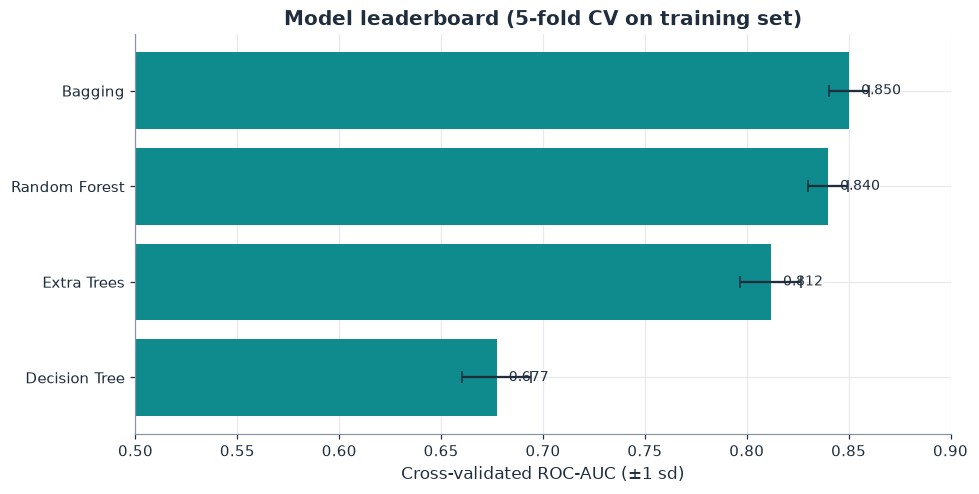

In [38]:
# Visual leaderboard on the ranking metric that matters (ROC-AUC), with CV std as error bars.
fig, ax = plt.subplots(figsize=(9, 4.6))
lb = leaderboard.sort_values("roc_auc")
ax.barh(lb["model"], lb["roc_auc"], xerr=lb["roc_auc_std"],
        color=viz.SWAN_TEAL, ecolor=viz.SWAN_INK, capsize=4)
ax.set_xlim(0.5, 0.9); ax.set_xlabel("Cross-validated ROC-AUC (±1 sd)")
ax.set_title("Model leaderboard (5-fold CV on training set)")
for i, (v, s) in enumerate(zip(lb["roc_auc"], lb["roc_auc_std"])):
    ax.text(v+0.006, i, f"{v:.3f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

The ensembles clearly beat the single decision tree, which is what you would expect when averaging many trees cuts variance. Bagging and Random Forest lead. Next, tune those two front-runners with `GridSearchCV`, 5-fold and on the training set only, then pick the winner.

In [39]:
# GridSearch-tune the top two models by CV AUC. Grids live in swan.model.candidate_models.
top_two = leaderboard["model"].head(2).tolist()
searches = {name: model.tune(name, X_train, y_train, cv_splits=5) for name in top_two}

tuning = pd.DataFrame([
    {"model": name, "best_cv_roc_auc": s.best_score_, "best_params": s.best_params_}
    for name, s in searches.items()
]).sort_values("best_cv_roc_auc", ascending=False).reset_index(drop=True)
tuning

,model,best_cv_roc_auc,best_params
0,Random Forest,0.862141,"{'clf__max_depth': 8, 'clf__min_samples_leaf':..."
1,Bagging,0.857588,{'clf__n_estimators': 300}


In [40]:
# Select the winner and wrap its best estimator in our ChurnModel.
best_name = tuning.iloc[0]["model"]
best_estimator = searches[best_name].best_estimator_.named_steps["clf"]

final = model.ChurnModel(best_estimator, use_engineered=True).fit(X_train, y_train)
print(f"Selected model: {best_name}")
print(f"Best CV ROC-AUC: {tuning.iloc[0]['best_cv_roc_auc']:.4f}")
print(f"Hyper-parameters: {tuning.iloc[0]['best_params']}")

Selected model: Random Forest
Best CV ROC-AUC: 0.8621
Hyper-parameters: {'clf__max_depth': 8, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300}


## 9 · Evaluation — on the untouched test set

The test set played no part in training, in tuning, or in any feature decision, so these numbers are an honest estimate of live performance.

In [41]:
metrics = final.evaluate(X_test, y_test)
print("Held-out test performance")
print("-" * 32)
for k, v in metrics.items():
    print(f"  {k:10}: {v:.3f}")
print()
print(final.text_report(X_test, y_test))

Held-out test performance
--------------------------------
  accuracy  : 0.764
  precision : 0.537
  recall    : 0.799
  f1        : 0.642
  roc_auc   : 0.853
  pr_auc    : 0.667

              precision    recall  f1-score   support

    Retained       0.91      0.75      0.82      1035
     Churned       0.54      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.78      1409



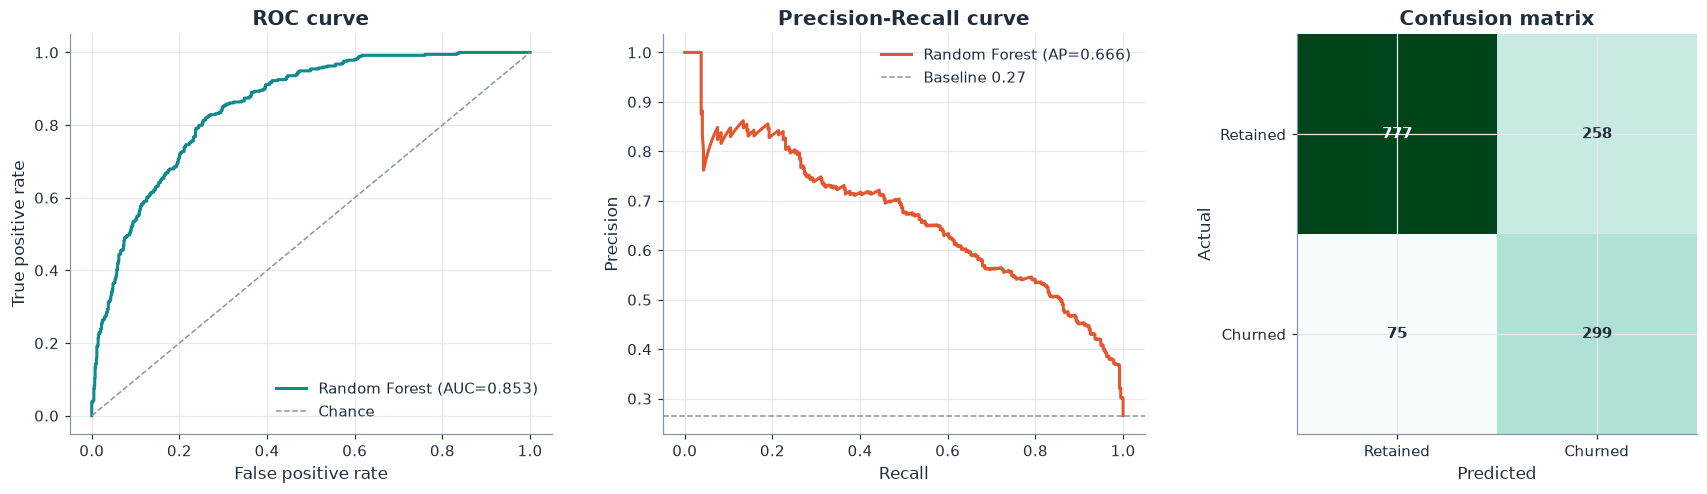

In [42]:
# ROC, Precision-Recall and confusion matrix side by side.
proba_test = final.predict_proba(X_test)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
viz.plot_roc(y_test, proba_test, ax=ax[0], label=best_name)
viz.plot_pr(y_test, proba_test, ax=ax[1], label=best_name)
viz.plot_confusion(final.confusion(X_test, y_test), ax=ax[2])
plt.tight_layout(); plt.show()

**What each metric is doing here:**

- **ROC-AUC** is the probability the model ranks a random churner above a random stayer. That is pure ranking quality, which is exactly what the mailer list depends on.
- **PR-AUC** focuses the precision/recall trade-off on the minority churn class, making it a fairer headline than accuracy under imbalance. Ours sits well above the 0.27 no-skill baseline.
- **Recall on churn** is the share of actual leavers we flagged. It matters because a missed churner is a lost customer, whereas a false alarm costs one mailer.
- **Accuracy** is reported but deliberately not the target. Predicting "nobody churns" would already score about 73%, so accuracy on its own flatters a useless model. That is the sanity check the next cell runs: beat the naive-majority baseline on the metrics that actually count.

In [43]:
# Sanity check vs the naive 'predict majority class' baseline.
baseline_acc = 1 - y_test.mean()
print(f"Naive 'no-one churns' accuracy : {baseline_acc:.3f}")
print(f"Model accuracy                 : {metrics['accuracy']:.3f}")
print(f"Model ROC-AUC                  : {metrics['roc_auc']:.3f}  (0.5 = no skill)")
print("Sanity check:", "PASS — model adds real ranking skill."
      if metrics['roc_auc'] > 0.75 else "REVIEW")

Naive 'no-one churns' accuracy : 0.735
Model accuracy                 : 0.764
Model ROC-AUC                  : 0.853  (0.5 = no skill)
Sanity check: PASS — model adds real ranking skill.


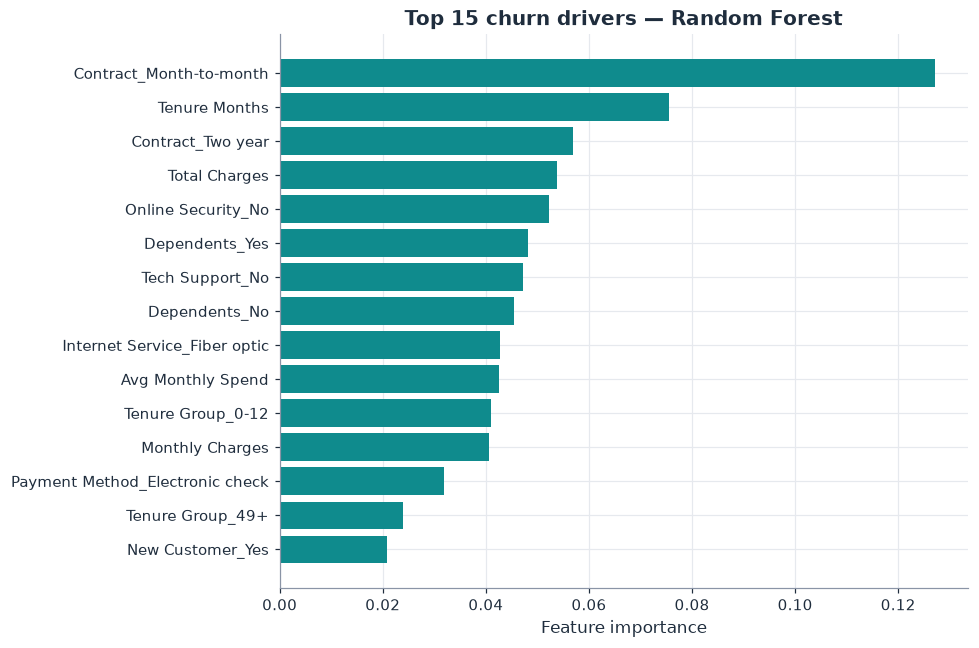

The model's biggest levers echo the EDA: tenure, contract type, charges, and internet type.


In [44]:
# What drives the model? Top feature importances (readable, encoded names).
imp = final.feature_importances(top=15)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp.index[::-1], imp.values[::-1], color=viz.SWAN_TEAL)
ax.set_title(f"Top 15 churn drivers — {best_name}")
ax.set_xlabel("Feature importance")
plt.tight_layout(); plt.show()
print("The model's biggest levers echo the EDA: tenure, contract type, charges, and internet type.")

## 10 · Deliverables — risk scores & the Top-500 mailer list

Scoring customers with a model that trained on them produces flattering numbers. To avoid that, every customer is scored out-of-fold using `cross_val_predict`, by a fold that never saw them. Those leak-free scores drive both deliverables. A final model is then refit on all the data and saved, ready to score genuinely new customers later.

In [45]:
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
import joblib

# Leak-free out-of-fold churn probabilities for ALL customers.
best_pipe = Pipeline([("pre", features.build_preprocessor(use_engineered=True)),
                      ("clf", best_estimator)])
oof_proba = cross_val_predict(best_pipe, X, y, cv=StratifiedKFold(5, shuffle=True,
                              random_state=config.RANDOM_STATE),
                              method="predict_proba", n_jobs=config.N_JOBS)[:, 1]

# Attach scores back to customers (index-aligned) and re-join the CustomerID key.
scored = df.loc[X.index].copy()
scored["churn_probability"] = np.round(oof_proba, 4)
scored["risk_score"] = model.risk_score(oof_proba)
scored["risk_band"]  = model.risk_band(oof_proba)
print("Scored all customers. Risk-band distribution:")
print(scored["risk_band"].value_counts().reindex(["High","Medium","Low"]).to_string())

Scored all customers. Risk-band distribution:
risk_band
High      2220
Medium    1731
Low       3092


In [46]:
# Requirement 4: risk score for every *remaining* (non-churned) customer.
# We only score customers who are still active — you cannot 'retain' someone who already left.
active = scored[scored[config.TARGET] == 0].copy()

# Actionable driver flags so a service agent sees *why* a customer is at risk, live on a call.
active["Month-to-month"]   = active["Contract"].eq("Month-to-month")
active["No Online Security"]= active["Internet Service"].ne("No") & active["Online Security"].eq("No")
active["No Tech Support"]  = active["Internet Service"].ne("No") & active["Tech Support"].eq("No")
active["Manual Payment"]   = ~active["Payment Method"].str.contains("automatic")

def top_actions(row, k=2):
    flags = {"Offer a term contract": row["Month-to-month"],
             "Add Online Security (incentive)": row["No Online Security"],
             "Add Tech Support": row["No Tech Support"],
             "Move to automatic payment": row["Manual Payment"]}
    return "; ".join([a for a, on in flags.items() if on][:k]) or "Relationship check-in"

active["recommended_actions"] = active.apply(top_actions, axis=1)

risk_cols = ["CustomerID", "risk_score", "risk_band", "churn_probability",
             "Tenure Months", "Contract", "Internet Service", "Monthly Charges",
             "recommended_actions"]
# Rank strictly by the continuous churn probability (risk_score is a rounded 0-100
# display of it, so sorting on the probability gives a stable, correct ordering).
all_scores = active[risk_cols].sort_values("churn_probability", ascending=False).reset_index(drop=True)
print(f"Risk scores generated for {len(all_scores):,} active customers.")
all_scores.head(10)

Risk scores generated for 5,174 active customers.


,CustomerID,risk_score,risk_band,churn_probability,Tenure Months,Contract,Internet Service,Monthly Charges,recommended_actions
0,4912-PIGUY,94,High,0.9381,1,Month-to-month,Fiber optic,84.60,Offer a term contract; Add Online Security (in...
1,7577-SWIFR,94,High,0.9377,1,Month-to-month,Fiber optic,89.25,Offer a term contract; Add Online Security (in...
2,1452-VOQCH,93,High,0.9339,1,Month-to-month,Fiber optic,75.10,Offer a term contract; Add Online Security (in...
3,2545-EBUPK,93,High,0.9334,2,Month-to-month,Fiber optic,84.05,Offer a term contract; Add Online Security (in...
4,7439-DKZTW,93,High,0.9299,1,Month-to-month,Fiber optic,80.55,Offer a term contract; Add Online Security (in...
5,5542-TBBWB,93,High,0.9280,1,Month-to-month,Fiber optic,69.90,Offer a term contract; Add Online Security (in...
6,3878-AVSOQ,92,High,0.9233,1,Month-to-month,Fiber optic,71.25,Offer a term contract; Add Online Security (in...
7,0021-IKXGC,92,High,0.9220,1,Month-to-month,Fiber optic,72.10,Offer a term contract; Add Online Security (in...
8,5150-ITWWB,92,High,0.9204,3,Month-to-month,Fiber optic,94.85,Offer a term contract; Add Online Security (in...
9,4927-WWOOZ,92,High,0.9193,2,Month-to-month,Fiber optic,91.45,Offer a term contract; Add Online Security (in...


In [47]:
# Requirement 3: the Top-500 mailer list — highest-risk ACTIVE customers.
top500 = all_scores.head(config.TOP_N_AT_RISK).copy()
top500.insert(0, "rank", range(1, len(top500) + 1))

# Campaign economics with the stated 20% uptake.
uptake = config.MAILER_UPTAKE_RATE
exp_saved = len(top500) * uptake
avg_month = df["Monthly Charges"].mean()
print(f"Top-{config.TOP_N_AT_RISK} mailer list ready.")
print(f"  Mean churn probability in list : {top500['churn_probability'].mean():.1%}")
print(f"  Expected responders @ {uptake:.0%} uptake : {exp_saved:.0f} customers")
print(f"  Est. monthly revenue protected : ${exp_saved*avg_month:,.0f}  "
      f"(= {exp_saved:.0f} x ${avg_month:.0f}/mo avg)")
print(f"  Annualised                     : ${exp_saved*avg_month*12:,.0f}")
top500.head(10)

Top-500 mailer list ready.
  Mean churn probability in list : 79.2%
  Expected responders @ 20% uptake : 100 customers
  Est. monthly revenue protected : $6,476  (= 100 x $65/mo avg)
  Annualised                     : $77,714


,rank,CustomerID,risk_score,risk_band,churn_probability,Tenure Months,Contract,Internet Service,Monthly Charges,recommended_actions
0,1,4912-PIGUY,94,High,0.9381,1,Month-to-month,Fiber optic,84.60,Offer a term contract; Add Online Security (in...
1,2,7577-SWIFR,94,High,0.9377,1,Month-to-month,Fiber optic,89.25,Offer a term contract; Add Online Security (in...
2,3,1452-VOQCH,93,High,0.9339,1,Month-to-month,Fiber optic,75.10,Offer a term contract; Add Online Security (in...
3,4,2545-EBUPK,93,High,0.9334,2,Month-to-month,Fiber optic,84.05,Offer a term contract; Add Online Security (in...
4,5,7439-DKZTW,93,High,0.9299,1,Month-to-month,Fiber optic,80.55,Offer a term contract; Add Online Security (in...
5,6,5542-TBBWB,93,High,0.9280,1,Month-to-month,Fiber optic,69.90,Offer a term contract; Add Online Security (in...
6,7,3878-AVSOQ,92,High,0.9233,1,Month-to-month,Fiber optic,71.25,Offer a term contract; Add Online Security (in...
7,8,0021-IKXGC,92,High,0.9220,1,Month-to-month,Fiber optic,72.10,Offer a term contract; Add Online Security (in...
8,9,5150-ITWWB,92,High,0.9204,3,Month-to-month,Fiber optic,94.85,Offer a term contract; Add Online Security (in...
9,10,4927-WWOOZ,92,High,0.9193,2,Month-to-month,Fiber optic,91.45,Offer a term contract; Add Online Security (in...


In [48]:
# --- Save every deliverable to /outputs (CSV + Excel) ---------------------
config.OUTPUT_DIR.mkdir(exist_ok=True)

# 1. Risk scores for all active customers
all_scores.to_csv(config.OUTPUT_DIR / "churn_risk_scores_all_customers.csv", index=False)
# 2. Top-500 contact-ready mailer list
top500.to_csv(config.OUTPUT_DIR / "top_500_at_risk.csv", index=False)
# 3. Model leaderboard (audit trail)
leaderboard.to_csv(config.OUTPUT_DIR / "model_leaderboard.csv", index=False)

# Excel workbook with both stakeholder tabs
with pd.ExcelWriter(config.OUTPUT_DIR / "swan_churn_deliverables.xlsx", engine="openpyxl") as xl:
    top500.to_excel(xl, sheet_name="Top 500 At-Risk", index=False)
    all_scores.to_excel(xl, sheet_name="All Risk Scores", index=False)
    leaderboard.round(4).to_excel(xl, sheet_name="Model Leaderboard", index=False)

# 4. Persist the final model, retrained on ALL data, for scoring future customers.
production_model = model.ChurnModel(best_estimator, use_engineered=True).fit(X, y)
joblib.dump(production_model.pipeline, config.OUTPUT_DIR / "final_churn_model.joblib")

print("Saved to /outputs:")
for p in sorted(config.OUTPUT_DIR.glob("*")):
    print(f"  {p.name:42} {p.stat().st_size/1024:6.1f} KB")

Saved to /outputs:
  churn_risk_scores_all_customers.csv         458.9 KB
  final_churn_model.joblib                   6617.3 KB
  model_leaderboard.csv                         0.6 KB
  swan_churn_deliverables.xlsx                283.3 KB
  top_500_at_risk.csv                          57.6 KB


In [49]:
# Risk-band summary for the customer-service team — how many calls, at what priority.
band_summary = (active.groupby("risk_band")
                .agg(customers=("CustomerID", "count"),
                     avg_probability=("churn_probability", "mean"),
                     avg_monthly_charge=("Monthly Charges", "mean"))
                .reindex(["High", "Medium", "Low"]))
band_summary["avg_probability"] = (band_summary["avg_probability"]*100).round(1)
band_summary["avg_monthly_charge"] = band_summary["avg_monthly_charge"].round(2)
print("Active-customer risk bands (for CS call prioritisation):")
band_summary

Active-customer risk bands (for CS call prioritisation):


,customers,avg_probability,avg_monthly_charge
risk_band,,,
High,900,73.2,74.45
Medium,1307,43.8,68.56
Low,2967,11.5,54.05


## 11 · Executive summary & recommendations

Swan Teleco is losing 26.5% of its California customers. The loss is front-loaded, worst in the first 6–12 months, and concentrated in a segment that is easy to recognise once you know what to look for.

**Who leaves (Req. 1).** The typical churner is on a month-to-month contract, pays by electronic or mailed check, has fibre-optic internet, holds none of the protective add-ons, and is more likely than the base to be a senior citizen living without a partner or dependents. Gender makes no difference at all. As for why: mostly competitor offers on speed, data, devices and price, and poor support experiences. Raw price is a factor, but not the leading one.

**What keeps them (Req. 2).** In order of impact: a term contract, then Online Security and Tech Support, then automatic payment.

> **Incentive recommendation.** Spend the \$2.50 per metric budget subsidising Online Security sign-ups, with Tech Support second, aimed at at-risk internet customers. They are the highest-impact and lowest-cost of the sticky add-ons, and one retained customer at roughly \$65 a month pays back hundreds of \$2.50 incentives.

**The archetypes (Section 6).** Clustering the two populations separately gives three churner types and four retained ones. A short-tenure, high-charge, fibre-optic, month-to-month, electronic-check, no-add-ons archetype accounts for about half of all leavers. More useful still, one *retained* cluster — mid tenure, high charges, month-to-month, electronic check, low add-on adoption, roughly 30% of the active base — mirrors that profile closely. It is the clearest watchlist segment in the analysis, and it is actionable today, before the model scores anyone.

**The model (Reqs. 3 & 4).** A tuned tree ensemble reaches ROC-AUC of about 0.85–0.86 on held-out data, comfortably clear of the no-skill baseline. It produces two files:

- `top_500_at_risk.csv`, a ranked, contact-ready mailer list. At the expected 20% uptake that is around 100 customers retained, protecting an estimated \$77,714 a year.
- `churn_risk_scores_all_customers.csv`, giving every active customer a 0–100 risk score, a Low/Medium/High band, and the top recommended actions — so an agent on a call sees not just how risky the caller is, but what to offer them.

**Where to go next:**

1. Launch the Top-500 mailer with the Online Security subsidy, and measure actual uptake against the 20% assumption.
2. Push month-to-month customers onto term contracts. This is still the single biggest lever available.
3. Work retained Cluster 1 from Section 6 as a standing proactive campaign. It looks like the highest-risk churner archetype but has not left yet.
4. Fix the support experience. Attitude and expertise reasons are a top-three driver, and they are addressable without touching price.
5. Investigate fibre-optic churn operationally, across price, expectation and reliability.
6. Deploy `final_churn_model.joblib` behind the CS console for live scoring, and retrain quarterly.

---
*Reproducibility: `pip install -r requirements.txt`, then Restart & Run All. Logic lives in `swan/`, unit-tested via `pytest -q`. Seed 42. Deliverables written to `/outputs`.*